In [1]:

# ============================================================
# SECTION 1 — ENVIRONMENT SETUP
# ============================================================

import os
import sys
import time
import json
import random
import hashlib
import shutil
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# ------------------------------------------------------------
# Random seed
# ------------------------------------------------------------

RANDOM_SEED = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ------------------------------------------------------------
# Environment information
# ------------------------------------------------------------

print("=" * 60)
print("ENVIRONMENT INFORMATION")
print("=" * 60)

print("Python Version     :", sys.version)
print("TensorFlow Version :", tf.__version__)

try:
    print("Keras Version      :", keras.__version__)
except:
    print("Keras Version      : Integrated with TensorFlow")


# ------------------------------------------------------------
# GPU check
# ------------------------------------------------------------

gpus = tf.config.list_physical_devices("GPU")

print("\nGPU Available:", len(gpus) > 0)

if len(gpus) > 0:

    for gpu in gpus:
        print("GPU:", gpu.name)

    try:
        gpu_name = tf.test.gpu_device_name()

        print("GPU Device Name:", gpu_name)

    except Exception as e:
        print("Unable to obtain GPU name:", e)

else:

    print("""
WARNING:
No GPU detected.

In Google Colab go to:

Runtime
→ Change runtime type
→ Hardware accelerator
→ T4 GPU
""")


# ------------------------------------------------------------
# Main directories
# ------------------------------------------------------------

PROJECT_ROOT = Path("/content")

OUTPUT_DIR = PROJECT_ROOT / "outputs"

PLOTS_DIR = OUTPUT_DIR / "plots"

GRADCAM_DIR = OUTPUT_DIR / "gradcam"

MODELS_DIR = PROJECT_ROOT / "models"

RESULTS_DIR = PROJECT_ROOT / "results"

RESEARCH_RESULTS_DIR = PROJECT_ROOT / "research_results"


# ------------------------------------------------------------
# Create directories
# ------------------------------------------------------------

directories = [

    OUTPUT_DIR,
    PLOTS_DIR,
    GRADCAM_DIR,
    MODELS_DIR,
    RESULTS_DIR,
    RESEARCH_RESULTS_DIR

]

for directory in directories:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# Display created directories
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PROJECT DIRECTORIES")
print("=" * 60)

for directory in directories:
    print(directory)


print("\nEnvironment setup completed successfully.")

ENVIRONMENT INFORMATION
Python Version     : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
TensorFlow Version : 2.20.0
Keras Version      : 3.13.2

GPU Available: True
GPU: /physical_device:GPU:0
GPU Device Name: /device:GPU:0

PROJECT DIRECTORIES
/content/outputs
/content/outputs/plots
/content/outputs/gradcam
/content/models
/content/results
/content/research_results

Environment setup completed successfully.


In [2]:
# ============================================================
# SECTION 2 — UPLOAD DATASET ZIP
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving image_dataset.zip to image_dataset.zip


In [3]:
ZIP_PATH = Path("/content/image_dataset.zip")

print("ZIP exists:", ZIP_PATH.exists())
print("ZIP path:", ZIP_PATH)

ZIP exists: True
ZIP path: /content/image_dataset.zip


In [4]:
# ============================================================
# SECTION 2.1 — EXTRACT DATASET
# ============================================================

ZIP_PATH = Path("/content/image_dataset.zip")

EXTRACT_DIR = Path("/content/dataset_extracted")


# Remove previous extraction if necessary
if EXTRACT_DIR.exists():

    shutil.rmtree(EXTRACT_DIR)


EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Extract ZIP
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:

    zip_ref.extractall(EXTRACT_DIR)


print("Dataset extracted successfully.")

print("Extraction directory:")
print(EXTRACT_DIR)

Dataset extracted successfully.
Extraction directory:
/content/dataset_extracted


In [5]:
print("\nTop-level files/folders:")

for item in EXTRACT_DIR.iterdir():

    print(item)


Top-level files/folders:
/content/dataset_extracted/image_dataset


In [6]:
# ============================================================
# SECTION 2.2 — LOCATE CLASS DIRECTORIES
# ============================================================

def find_class_folder(root_directory, target_name):

    root_directory = Path(root_directory)

    for path in root_directory.rglob("*"):

        if (
            path.is_dir()
            and path.name.lower() == target_name.lower()
        ):

            return path

    return None


REAL_DIR = find_class_folder(
    EXTRACT_DIR,
    "real"
)

FAKE_DIR = find_class_folder(
    EXTRACT_DIR,
    "fake"
)


print("REAL directory:", REAL_DIR)
print("FAKE directory:", FAKE_DIR)


if REAL_DIR is None:
    raise FileNotFoundError(
        "Could not find the REAL/Real folder."
    )

if FAKE_DIR is None:
    raise FileNotFoundError(
        "Could not find the FAKE/Fake folder."
    )


print("\nDataset folders detected successfully.")

REAL directory: /content/dataset_extracted/image_dataset/Real
FAKE directory: /content/dataset_extracted/image_dataset/Fake

Dataset folders detected successfully.


In [7]:
# ============================================================
# SECTION 3 — DATASET VERIFICATION
# ============================================================

VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png"
}


def collect_image_files(directory):

    directory = Path(directory)

    images = []

    invalid_format_files = []

    for file_path in directory.rglob("*"):

        if not file_path.is_file():
            continue

        if file_path.suffix.lower() in VALID_EXTENSIONS:

            images.append(file_path)

        else:

            invalid_format_files.append(file_path)

    return images, invalid_format_files


real_images, real_invalid_formats = collect_image_files(
    REAL_DIR
)

fake_images, fake_invalid_formats = collect_image_files(
    FAKE_DIR
)


print("=" * 60)
print("INITIAL DATASET SUMMARY")
print("=" * 60)

print("REAL Images :", len(real_images))
print("FAKE Images :", len(fake_images))

total_images = (
    len(real_images)
    +
    len(fake_images)
)

print("Total Images:", total_images)

INITIAL DATASET SUMMARY
REAL Images : 497
FAKE Images : 500
Total Images: 997


In [9]:
# ============================================================
# SECTION 3.1 — CLASS DISTRIBUTION
# ============================================================

real_count = len(real_images)

fake_count = len(fake_images)

total_count = real_count + fake_count


real_percentage = (
    real_count / total_count
) * 100

fake_percentage = (
    fake_count / total_count
) * 100


print("=" * 60)
print("DATASET CLASS DISTRIBUTION")
print("=" * 60)

print(f"Total Images : {total_count}")

print(
    f"REAL Images  : "
    f"{real_count} "
    f"({real_percentage:.2f}%)"
)

print(
    f"FAKE Images  : "
    f"{fake_count} "
    f"({fake_percentage:.2f}%)"
)

DATASET CLASS DISTRIBUTION
Total Images : 997
REAL Images  : 497 (49.85%)
FAKE Images  : 500 (50.15%)


In [10]:
# ============================================================
# SECTION 6 — VERIFY AND HANDLE INVALID IMAGES
# ============================================================

valid_image_records = []
invalid_image_records = []

all_images = [
    (path, "REAL", 0) for path in real_images
] + [
    (path, "FAKE", 1) for path in fake_images
]


print("Checking images...")
print("Total discovered images:", len(all_images))


for index, (image_path, label, label_id) in enumerate(all_images):

    try:

        # Check that the file still exists
        if not image_path.exists():

            invalid_image_records.append({
                "filepath": str(image_path),
                "label": label,
                "reason": "File does not exist"
            })

            continue


        # Open image
        with Image.open(image_path) as img:

            # Force PIL to actually read image data
            img.load()

            width, height = img.size

            # Validate dimensions
            if width <= 0 or height <= 0:

                invalid_image_records.append({
                    "filepath": str(image_path),
                    "label": label,
                    "reason": "Invalid image dimensions"
                })

                continue


            # Verify that image can be converted to RGB
            rgb_image = img.convert("RGB")

            # Force RGB conversion to complete
            rgb_image.load()


        valid_image_records.append({
            "filepath": str(image_path),
            "label": label,
            "label_id": label_id,
            "width": width,
            "height": height
        })


    except (
        UnidentifiedImageError,
        OSError,
        ValueError,
        Exception
    ) as e:

        invalid_image_records.append({
            "filepath": str(image_path),
            "label": label,
            "reason": str(e)
        })


print("\n" + "=" * 60)
print("IMAGE VALIDATION RESULTS")
print("=" * 60)

print("Valid images  :", len(valid_image_records))
print("Invalid images:", len(invalid_image_records))

Checking images...
Total discovered images: 997

IMAGE VALIDATION RESULTS
Valid images  : 968
Invalid images: 29


In [11]:
# ============================================================
# SECTION 6.1 — INVALID IMAGE REPORT
# ============================================================

invalid_df = pd.DataFrame(
    invalid_image_records
)


if len(invalid_df) > 0:

    print("Invalid images detected:")

    display(invalid_df)

    invalid_report_path = (
        RESULTS_DIR /
        "invalid_images.csv"
    )

    invalid_df.to_csv(
        invalid_report_path,
        index=False
    )

    print(
        "\nInvalid image report saved to:",
        invalid_report_path
    )

else:

    print(
        "No corrupted or unreadable images detected."
    )

Invalid images detected:


,filepath,label,reason
0,/content/dataset_extracted/image_dataset/Real/...,REAL,image file is truncated (32 bytes not processed)
1,/content/dataset_extracted/image_dataset/Real/...,REAL,image file is truncated (29 bytes not processed)
2,/content/dataset_extracted/image_dataset/Real/...,REAL,image file is truncated (32 bytes not processed)
3,/content/dataset_extracted/image_dataset/Real/...,REAL,image file is truncated (10 bytes not processed)
4,/content/dataset_extracted/image_dataset/Real/...,REAL,image file is truncated (20 bytes not processed)
5,/content/dataset_extracted/image_dataset/Real/...,REAL,image file is truncated (22 bytes not processed)
6,/content/dataset_extracted/image_dataset/Real/...,REAL,image file is truncated (29 bytes not processed)
7,/content/dataset_extracted/image_dataset/Real/...,REAL,image file is truncated (34 bytes not processed)
8,/content/dataset_extracted/image_dataset/Real/...,REAL,image file is truncated (26 bytes not processed)
9,/content/dataset_extracted/image_dataset/Real/...,REAL,image file is truncated (5 bytes not processed)



Invalid image report saved to: /content/results/invalid_images.csv


In [12]:
# ============================================================
# SECTION 7 — CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(
    valid_image_records
)


# Keep required columns first
df = df[
    [
        "filepath",
        "label",
        "label_id",
        "width",
        "height"
    ]
]


print("=" * 60)
print("DATAFRAME")
print("=" * 60)


print("\nFirst 10 rows:")

display(
    df.head(10)
)


print("\nDataset shape:")

print(df.shape)


print("\nLabel counts:")

print(
    df["label"]
    .value_counts()
)


print("\nLabel ID counts:")

print(
    df["label_id"]
    .value_counts()
)

DATAFRAME

First 10 rows:


,filepath,label,label_id,width,height
0,/content/dataset_extracted/image_dataset/Real/...,REAL,0,549,297
1,/content/dataset_extracted/image_dataset/Real/...,REAL,0,569,280
2,/content/dataset_extracted/image_dataset/Real/...,REAL,0,600,400
3,/content/dataset_extracted/image_dataset/Real/...,REAL,0,550,310
4,/content/dataset_extracted/image_dataset/Real/...,REAL,0,550,310
5,/content/dataset_extracted/image_dataset/Real/...,REAL,0,600,400
6,/content/dataset_extracted/image_dataset/Real/...,REAL,0,630,355
7,/content/dataset_extracted/image_dataset/Real/...,REAL,0,550,310
8,/content/dataset_extracted/image_dataset/Real/...,REAL,0,675,445
9,/content/dataset_extracted/image_dataset/Real/...,REAL,0,550,310



Dataset shape:
(968, 5)

Label counts:
label
FAKE    500
REAL    468
Name: count, dtype: int64

Label ID counts:
label_id
1    500
0    468
Name: count, dtype: int64


In [13]:
# ============================================================
# SECTION 7.1 — DUPLICATE FILE PATH CHECK
# ============================================================

duplicate_paths = df[
    df.duplicated(
        subset=["filepath"],
        keep=False
    )
]


print(
    "Duplicate file paths:",
    len(duplicate_paths)
)


if len(duplicate_paths) > 0:

    display(
        duplicate_paths.sort_values(
            "filepath"
        )
    )

else:

    print(
        "No duplicate file paths detected."
    )

Duplicate file paths: 0
No duplicate file paths detected.


In [14]:
# ============================================================
# SECTION 7.2 — IMAGE CONTENT HASH
# ============================================================

def calculate_image_hash(image_path):

    try:

        with Image.open(image_path) as img:

            # Standardize representation
            img = img.convert("RGB")

            image_array = np.asarray(img)

            # Include dimensions so shape is part of hash
            hash_object = hashlib.sha256()

            hash_object.update(
                str(image_array.shape).encode("utf-8")
            )

            hash_object.update(
                image_array.tobytes()
            )

            return hash_object.hexdigest()


    except Exception as e:

        print(
            f"Hashing failed: {image_path}"
        )

        print(e)

        return None

In [15]:
print("Calculating image hashes...")

df["image_hash"] = df["filepath"].apply(
    calculate_image_hash
)

print("Hash calculation completed.")

Calculating image hashes...
Hash calculation completed.


In [16]:
display(
    df.head()
)

,filepath,label,label_id,width,height,image_hash
0,/content/dataset_extracted/image_dataset/Real/...,REAL,0,549,297,352e83cce9dc1cc8c04bd7f5e5f017cbf0c24ace4cfcef...
1,/content/dataset_extracted/image_dataset/Real/...,REAL,0,569,280,191c3235178a1708107983cca394e23e6e62f739874b49...
2,/content/dataset_extracted/image_dataset/Real/...,REAL,0,600,400,29431920aff91ee5c1e84c1b2ecdb2299cfa9353e79b5f...
3,/content/dataset_extracted/image_dataset/Real/...,REAL,0,550,310,20f68b35a80f1fc03130258f753e5e13fed0c9b2fb78ca...
4,/content/dataset_extracted/image_dataset/Real/...,REAL,0,550,310,5ca7c22b66b65f7001afc6c7c992e2df2c302c575a5109...


In [17]:
# ============================================================
# SECTION 7.3 — FIND IMAGE DUPLICATES
# ============================================================

duplicate_images = df[
    df.duplicated(
        subset=["image_hash"],
        keep=False
    )
].sort_values(
    "image_hash"
)


print(
    "Rows involved in exact image duplicates:",
    len(duplicate_images)
)


if len(duplicate_images) > 0:

    display(
        duplicate_images[
            [
                "filepath",
                "label",
                "image_hash"
            ]
        ]
    )

else:

    print(
        "No exact duplicate images detected."
    )

Rows involved in exact image duplicates: 14


,filepath,label,image_hash
299,/content/dataset_extracted/image_dataset/Real/...,REAL,1d74fa4d2979ecd4731293ac77bca996d673dcd32dfdd4...
420,/content/dataset_extracted/image_dataset/Real/...,REAL,1d74fa4d2979ecd4731293ac77bca996d673dcd32dfdd4...
31,/content/dataset_extracted/image_dataset/Real/...,REAL,3044475987ec6f53f973f9f4d60a42149407bf56e95955...
309,/content/dataset_extracted/image_dataset/Real/...,REAL,3044475987ec6f53f973f9f4d60a42149407bf56e95955...
11,/content/dataset_extracted/image_dataset/Real/...,REAL,3563d2bb5c6728fb95fcfeea312dfa6a72157d5eeaa414...
385,/content/dataset_extracted/image_dataset/Real/...,REAL,3563d2bb5c6728fb95fcfeea312dfa6a72157d5eeaa414...
394,/content/dataset_extracted/image_dataset/Real/...,REAL,3b1c370aec495b5b82850f64da7c193b6a69bbd32c5a43...
464,/content/dataset_extracted/image_dataset/Real/...,REAL,3b1c370aec495b5b82850f64da7c193b6a69bbd32c5a43...
388,/content/dataset_extracted/image_dataset/Real/...,REAL,7940493459a317d43b7a644283eee79a4d2decb89b45b2...
462,/content/dataset_extracted/image_dataset/Real/...,REAL,7940493459a317d43b7a644283eee79a4d2decb89b45b2...


In [18]:
# ============================================================
# SECTION 7.4 — CONFLICTING DUPLICATE LABELS
# ============================================================

hash_label_counts = (
    df.groupby("image_hash")["label"]
    .nunique()
)


conflicting_hashes = (
    hash_label_counts[
        hash_label_counts > 1
    ]
    .index
    .tolist()
)


conflicting_duplicates = df[
    df["image_hash"].isin(
        conflicting_hashes
    )
]


print(
    "Conflicting duplicate image groups:",
    len(conflicting_hashes)
)

print(
    "Rows involved in conflicting duplicates:",
    len(conflicting_duplicates)
)


if len(conflicting_duplicates) > 0:

    display(
        conflicting_duplicates.sort_values(
            "image_hash"
        )
    )

else:

    print(
        "No images with conflicting REAL/FAKE labels detected."
    )

Conflicting duplicate image groups: 0
Rows involved in conflicting duplicates: 0
No images with conflicting REAL/FAKE labels detected.


In [19]:
# ============================================================
# SECTION 7.5 — CLEAN DUPLICATES
# ============================================================

original_dataframe_size = len(df)


# ------------------------------------------------------------
# Remove images having conflicting labels
# ------------------------------------------------------------

if len(conflicting_hashes) > 0:

    df_clean = df[
        ~df["image_hash"].isin(
            conflicting_hashes
        )
    ].copy()

else:

    df_clean = df.copy()


# ------------------------------------------------------------
# Remove exact same-label duplicates
# Keep the first copy only
# ------------------------------------------------------------

df_clean = df_clean.drop_duplicates(
    subset=["image_hash"],
    keep="first"
)


df_clean = df_clean.reset_index(
    drop=True
)


removed_duplicates = (
    original_dataframe_size
    -
    len(df_clean)
)


print("=" * 60)
print("DUPLICATE CLEANING")
print("=" * 60)

print(
    "Original valid images:",
    original_dataframe_size
)

print(
    "Final unique images:",
    len(df_clean)
)

print(
    "Images removed:",
    removed_duplicates
)

DUPLICATE CLEANING
Original valid images: 968
Final unique images: 961
Images removed: 7


In [20]:
# ============================================================
# SECTION 7.6 — FINAL CLEAN DATASET CHECK
# ============================================================

print("=" * 60)
print("FINAL CLEAN DATASET")
print("=" * 60)


print("\nDataset shape:")

print(
    df_clean.shape
)


print("\nClass counts:")

print(
    df_clean["label"]
    .value_counts()
)


print("\nClass percentages:")

class_percentages = (
    df_clean["label"]
    .value_counts(
        normalize=True
    )
    * 100
)

print(
    class_percentages
)


print(
    "\nRemaining duplicate hashes:",
    df_clean["image_hash"]
    .duplicated()
    .sum()
)

FINAL CLEAN DATASET

Dataset shape:
(961, 6)

Class counts:
label
FAKE    500
REAL    461
Name: count, dtype: int64

Class percentages:
label
FAKE    52.029136
REAL    47.970864
Name: proportion, dtype: float64

Remaining duplicate hashes: 0


In [21]:
clean_dataset_csv = (
    RESULTS_DIR /
    "clean_dataset_metadata.csv"
)


df_clean.to_csv(
    clean_dataset_csv,
    index=False
)


print(
    "Clean dataset metadata saved to:",
    clean_dataset_csv
)

Clean dataset metadata saved to: /content/results/clean_dataset_metadata.csv


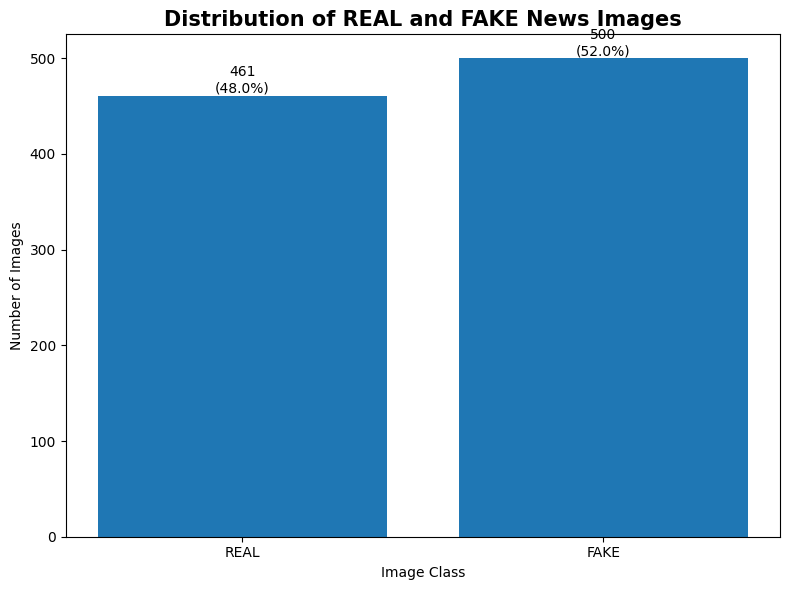

Saved: /content/outputs/plots/class_distribution_bar.png


In [22]:
# ============================================================
# SECTION 4 — CLASS DISTRIBUTION BAR CHART
# ============================================================

class_counts = (
    df_clean["label"]
    .value_counts()
    .reindex(
        ["REAL", "FAKE"]
    )
)


total_clean_images = (
    class_counts.sum()
)


class_percentages = (
    class_counts /
    total_clean_images
    * 100
)


fig, ax = plt.subplots(
    figsize=(8, 6)
)


bars = ax.bar(
    class_counts.index,
    class_counts.values
)


ax.set_title(
    "Distribution of REAL and FAKE News Images",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Image Class"
)

ax.set_ylabel(
    "Number of Images"
)


for bar, count, percentage in zip(
    bars,
    class_counts.values,
    class_percentages.values
):

    height = bar.get_height()

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        height,
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        va="bottom"
    )


plt.tight_layout()


bar_chart_path = (
    PLOTS_DIR /
    "class_distribution_bar.png"
)


plt.savefig(
    bar_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Saved:",
    bar_chart_path
)

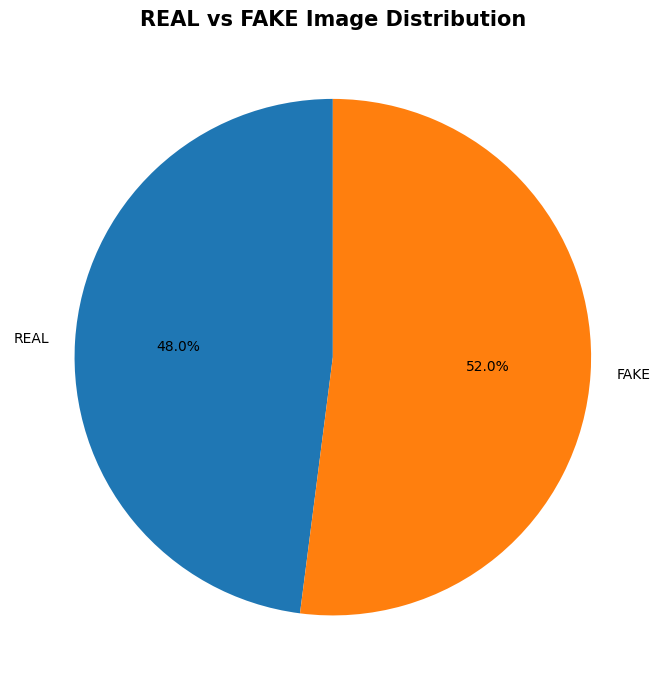

Saved: /content/outputs/plots/class_distribution_pie.png


In [23]:
# ============================================================
# SECTION 4.1 — PIE CHART
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 7)
)


ax.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct="%1.1f%%",
    startangle=90
)


ax.set_title(
    "REAL vs FAKE Image Distribution",
    fontsize=15,
    fontweight="bold"
)


plt.tight_layout()


pie_chart_path = (
    PLOTS_DIR /
    "class_distribution_pie.png"
)


plt.savefig(
    pie_chart_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    pie_chart_path
)

In [24]:
# ============================================================
# SECTION 5 — SAMPLE IMAGE VISUALIZATION
# ============================================================

NUM_SAMPLES_PER_CLASS = 8


real_samples = (
    df_clean[
        df_clean["label"] == "REAL"
    ]
    .sample(
        n=min(
            NUM_SAMPLES_PER_CLASS,
            len(
                df_clean[
                    df_clean["label"] == "REAL"
                ]
            )
        ),
        random_state=RANDOM_SEED
    )
)


fake_samples = (
    df_clean[
        df_clean["label"] == "FAKE"
    ]
    .sample(
        n=min(
            NUM_SAMPLES_PER_CLASS,
            len(
                df_clean[
                    df_clean["label"] == "FAKE"
                ]
            )
        ),
        random_state=RANDOM_SEED
    )
)

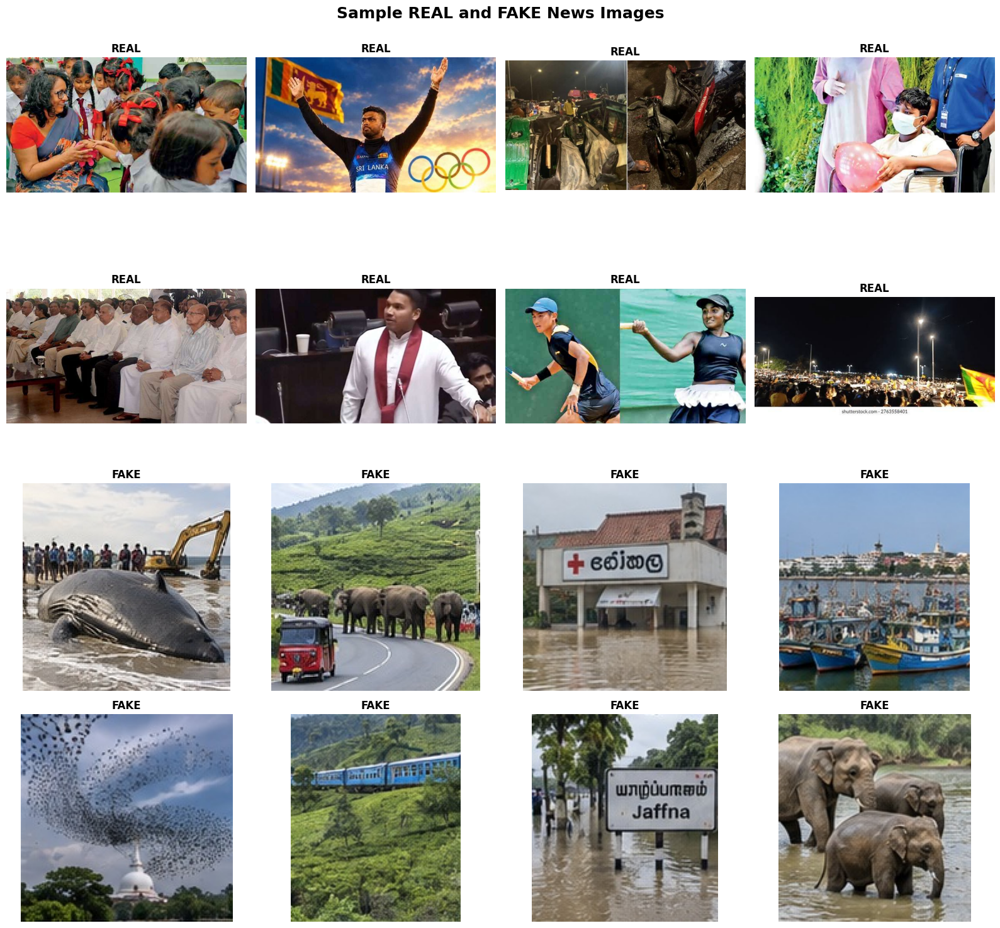

Saved: /content/outputs/plots/sample_images.png


In [25]:
sample_df = pd.concat(
    [
        real_samples,
        fake_samples
    ],
    ignore_index=True
)


fig, axes = plt.subplots(
    4,
    4,
    figsize=(16, 15)
)


axes = axes.flatten()


for ax, (_, row) in zip(
    axes,
    sample_df.iterrows()
):

    try:

        with Image.open(
            row["filepath"]
        ) as img:

            img = img.convert("RGB")

            ax.imshow(img)


        ax.set_title(
            row["label"],
            fontsize=12,
            fontweight="bold"
        )

        ax.axis("off")


    except Exception as e:

        ax.set_title(
            "Unable to display"
        )

        ax.axis("off")


for ax in axes[len(sample_df):]:
    ax.axis("off")


fig.suptitle(
    "Sample REAL and FAKE News Images",
    fontsize=18,
    fontweight="bold"
)


plt.tight_layout()


sample_plot_path = (
    PLOTS_DIR /
    "sample_images.png"
)


plt.savefig(
    sample_plot_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    sample_plot_path
)

In [26]:
# ============================================================
# SECTION 8 — TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    stratify=df_clean["label_id"],
    random_state=RANDOM_SEED
)

In [27]:
validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=RANDOM_SEED
)

In [28]:
train_df = train_df.reset_index(
    drop=True
)

validation_df = validation_df.reset_index(
    drop=True
)

test_df = test_df.reset_index(
    drop=True
)

In [29]:
# ============================================================
# SECTION 8.1 — SPLIT SUMMARY
# ============================================================

print("=" * 60)
print("DATASET SPLIT")
print("=" * 60)


print(
    "Training samples  :",
    len(train_df)
)

print(
    "Validation samples:",
    len(validation_df)
)

print(
    "Testing samples   :",
    len(test_df)
)


print("\nTotal:")

print(
    len(train_df)
    +
    len(validation_df)
    +
    len(test_df)
)

DATASET SPLIT
Training samples  : 672
Validation samples: 144
Testing samples   : 145

Total:
961


In [30]:
# ============================================================
# SECTION 8.2 — SPLIT CLASS DISTRIBUTION
# ============================================================

def print_split_distribution(
    dataframe,
    split_name
):

    print(
        "\n" + "=" * 50
    )

    print(
        split_name
    )

    print(
        "=" * 50
    )


    counts = (
        dataframe["label"]
        .value_counts()
        .reindex(
            ["REAL", "FAKE"],
            fill_value=0
        )
    )


    percentages = (
        counts /
        len(dataframe)
        * 100
    )


    for label in [
        "REAL",
        "FAKE"
    ]:

        print(
            f"{label}: "
            f"{counts[label]} "
            f"({percentages[label]:.2f}%)"
        )


print_split_distribution(
    train_df,
    "TRAINING SET"
)

print_split_distribution(
    validation_df,
    "VALIDATION SET"
)

print_split_distribution(
    test_df,
    "TEST SET"
)


TRAINING SET
REAL: 322 (47.92%)
FAKE: 350 (52.08%)

VALIDATION SET
REAL: 69 (47.92%)
FAKE: 75 (52.08%)

TEST SET
REAL: 70 (48.28%)
FAKE: 75 (51.72%)


In [31]:
# ============================================================
# SECTION 8.3 — DATA LEAKAGE CHECK
# ============================================================

train_hashes = set(
    train_df["image_hash"]
)

validation_hashes = set(
    validation_df["image_hash"]
)

test_hashes = set(
    test_df["image_hash"]
)


train_validation_overlap = (
    train_hashes
    .intersection(
        validation_hashes
    )
)


train_test_overlap = (
    train_hashes
    .intersection(
        test_hashes
    )
)


validation_test_overlap = (
    validation_hashes
    .intersection(
        test_hashes
    )
)


print(
    "Train ↔ Validation overlap:",
    len(train_validation_overlap)
)

print(
    "Train ↔ Test overlap:",
    len(train_test_overlap)
)

print(
    "Validation ↔ Test overlap:",
    len(validation_test_overlap)
)


assert len(
    train_validation_overlap
) == 0


assert len(
    train_test_overlap
) == 0


assert len(
    validation_test_overlap
) == 0


print(
    "\n✓ No exact-image leakage detected between splits."
)

Train ↔ Validation overlap: 0
Train ↔ Test overlap: 0
Validation ↔ Test overlap: 0

✓ No exact-image leakage detected between splits.


In [32]:
# ============================================================
# SECTION 8.4 — SAVE SPLITS
# ============================================================

train_df.to_csv(
    RESULTS_DIR / "train_split.csv",
    index=False
)


validation_df.to_csv(
    RESULTS_DIR / "validation_split.csv",
    index=False
)


test_df.to_csv(
    RESULTS_DIR / "test_split.csv",
    index=False
)


print(
    "Dataset split files saved successfully."
)

Dataset split files saved successfully.


In [33]:
# ============================================================
# SECTION 9 — IMAGE CONFIGURATION
# ============================================================

IMAGE_SIZE = (224, 224)

IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
CHANNELS = 3

BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE


print("=" * 60)
print("IMAGE CONFIGURATION")
print("=" * 60)

print("Image Height :", IMAGE_HEIGHT)
print("Image Width  :", IMAGE_WIDTH)
print("Channels     :", CHANNELS)
print("Batch Size   :", BATCH_SIZE)

print("\nModel input shape:")
print(
    (
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        CHANNELS
    )
)

IMAGE CONFIGURATION
Image Height : 224
Image Width  : 224
Channels     : 3
Batch Size   : 32

Model input shape:
(224, 224, 3)


In [34]:
# ============================================================
# SECTION 11 — IMAGE LOADING FUNCTION
# ============================================================

def load_and_resize_image(filepath, label):

    # Read image file
    image = tf.io.read_file(filepath)

    # Decode JPG/PNG automatically
    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Make TensorFlow know the channel dimension
    image.set_shape(
        [None, None, 3]
    )

    # Resize
    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        method="bilinear"
    )

    # Convert to float32
    image = tf.cast(
        image,
        tf.float32
    )

    # Binary label as float
    label = tf.cast(
        label,
        tf.float32
    )

    return image, label

In [35]:
# ============================================================
# SECTION 11.1 — CREATE TENSORFLOW DATASET FUNCTION
# ============================================================

def create_tf_dataset(
    dataframe,
    training=False
):

    filepaths = dataframe[
        "filepath"
    ].astype(str).values

    labels = dataframe[
        "label_id"
    ].astype(np.float32).values


    dataset = tf.data.Dataset.from_tensor_slices(
        (
            filepaths,
            labels
        )
    )


    # Shuffle ONLY training data
    if training:

        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )


    # Load images
    dataset = dataset.map(
        load_and_resize_image,
        num_parallel_calls=AUTOTUNE
    )


    # Cache decoded/resized images
    dataset = dataset.cache()


    # Batch
    dataset = dataset.batch(
        BATCH_SIZE
    )


    # Prefetch
    dataset = dataset.prefetch(
        AUTOTUNE
    )


    return dataset

In [36]:
# ============================================================
# SECTION 11.2 — CREATE DATASETS
# ============================================================

train_dataset = create_tf_dataset(
    train_df,
    training=True
)


validation_dataset = create_tf_dataset(
    validation_df,
    training=False
)


test_dataset = create_tf_dataset(
    test_df,
    training=False
)


print("TensorFlow datasets created successfully.")

print("\nTraining:")
print(train_dataset)

print("\nValidation:")
print(validation_dataset)

print("\nTesting:")
print(test_dataset)

TensorFlow datasets created successfully.

Training:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

Validation:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

Testing:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


In [37]:
# ============================================================
# SECTION 11.3 — VERIFY DATASET BATCH
# ============================================================

for images, labels in train_dataset.take(1):

    print("Image batch shape:")
    print(images.shape)

    print("\nLabel batch shape:")
    print(labels.shape)

    print("\nImage datatype:")
    print(images.dtype)

    print("\nLabels:")
    print(labels[:10])

Image batch shape:
(32, 224, 224, 3)

Label batch shape:
(32,)

Image datatype:
<dtype: 'float32'>

Labels:
tf.Tensor([1. 0. 0. 1. 0. 0. 0. 0. 1. 1.], shape=(10,), dtype=float32)


In [38]:
# ============================================================
# SECTION 10 — DATA AUGMENTATION
# ============================================================

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal",
            seed=RANDOM_SEED
        ),

        layers.RandomRotation(
            factor=0.05,
            seed=RANDOM_SEED
        ),

        layers.RandomZoom(
            height_factor=(-0.10, 0.10),
            width_factor=(-0.10, 0.10),
            seed=RANDOM_SEED
        ),

        layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
            seed=RANDOM_SEED
        ),

        layers.RandomContrast(
            factor=0.10,
            seed=RANDOM_SEED
        )
    ],
    name="data_augmentation"
)


print(
    "Training data augmentation created."
)

Training data augmentation created.


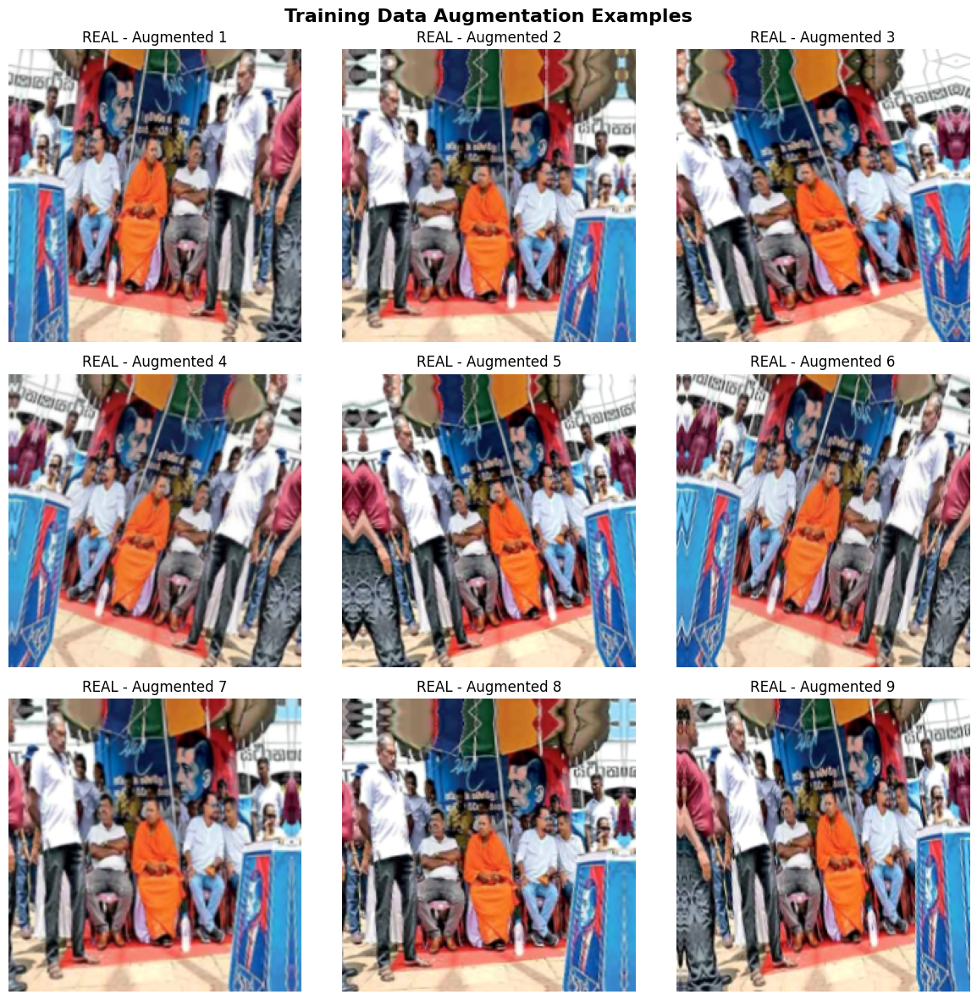

Saved: /content/outputs/plots/augmentation_examples.png


In [39]:
# ============================================================
# SECTION 10.1 — AUGMENTATION VISUALIZATION
# ============================================================

for image_batch, label_batch in train_dataset.take(1):

    sample_image = image_batch[0]

    sample_label_id = int(
        label_batch[0].numpy()
    )

    break


sample_label = (
    "FAKE"
    if sample_label_id == 1
    else "REAL"
)


plt.figure(
    figsize=(12, 12)
)


for i in range(9):

    augmented_image = data_augmentation(
        tf.expand_dims(
            sample_image,
            axis=0
        ),
        training=True
    )

    ax = plt.subplot(
        3,
        3,
        i + 1
    )

    plt.imshow(
        tf.cast(
            augmented_image[0],
            tf.uint8
        )
    )

    plt.title(
        f"{sample_label} - Augmented {i + 1}"
    )

    plt.axis("off")


plt.suptitle(
    "Training Data Augmentation Examples",
    fontsize=16,
    fontweight="bold"
)


plt.tight_layout()


augmentation_plot_path = (
    PLOTS_DIR /
    "augmentation_examples.png"
)


plt.savefig(
    augmentation_plot_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    augmentation_plot_path
)

In [40]:
# ============================================================
# SECTION 12 — LOAD MOBILENETV2 BASE MODEL
# ============================================================

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        CHANNELS
    ),
    include_top=False,
    weights="imagenet"
)


# Freeze pretrained layers initially
base_model.trainable = False


print(
    "MobileNetV2 base model loaded."
)

print(
    "Base model trainable:",
    base_model.trainable
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base model loaded.
Base model trainable: False


In [41]:
# ============================================================
# SECTION 12.1 — BUILD CLASSIFICATION MODEL
# ============================================================

inputs = keras.Input(
    shape=(
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        CHANNELS
    ),
    name="input_image"
)


# ------------------------------------------------------------
# Augmentation
# Executes only during training
# ------------------------------------------------------------

x = data_augmentation(
    inputs
)


# ------------------------------------------------------------
# MobileNetV2 preprocessing
#
# Converts image pixels approximately from:
#
# 0 ... 255
#
# into:
#
# -1 ... +1
# ------------------------------------------------------------

x = tf.keras.applications.mobilenet_v2.preprocess_input(
    x
)


# ------------------------------------------------------------
# MobileNetV2 feature extractor
#
# training=False is important because BatchNormalization
# statistics should not be updated during frozen training.
# ------------------------------------------------------------

x = base_model(
    x,
    training=False
)


# ------------------------------------------------------------
# Classification head
# ------------------------------------------------------------

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)


x = layers.Dropout(
    0.30,
    name="dropout_1"
)(x)


x = layers.Dense(
    128,
    activation="relu",
    name="dense_features"
)(x)


x = layers.Dropout(
    0.20,
    name="dropout_2"
)(x)


outputs = layers.Dense(
    1,
    activation="sigmoid",
    name="prediction"
)(x)


model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="MobileNetV2_Fake_News_Classifier"
)


print(
    "Model created successfully."
)

Model created successfully.


In [42]:
# ============================================================
# SECTION 12.2 — MODEL SUMMARY
# ============================================================

model.summary()

Model: "MobileNetV2_Fake_News_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_features (Dense)          │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [43]:
# ============================================================
# SECTION 12.3 — PARAMETER COUNTS
# ============================================================

total_params = model.count_params()


trainable_params = sum(
    np.prod(variable.shape)
    for variable in model.trainable_weights
)


non_trainable_params = sum(
    np.prod(variable.shape)
    for variable in model.non_trainable_weights
)


print("\n" + "=" * 60)
print("MODEL PARAMETERS")
print("=" * 60)


print(
    f"Total parameters:"
    f" {total_params:,}"
)


print(
    f"Trainable parameters:"
    f" {int(trainable_params):,}"
)


print(
    f"Non-trainable parameters:"
    f" {int(non_trainable_params):,}"
)


MODEL PARAMETERS
Total parameters: 2,422,081
Trainable parameters: 164,097
Non-trainable parameters: 2,257,984


In [45]:
# ============================================================
# SECTION 13 — COMPILE MODEL
# ============================================================

INITIAL_LEARNING_RATE = 1e-4


optimizer = tf.keras.optimizers.Adam(
    learning_rate=INITIAL_LEARNING_RATE
)


model.compile(

    optimizer=optimizer,

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)


print(
    "Model compiled successfully."
)


print(
    "Initial learning rate:",
    INITIAL_LEARNING_RATE
)

Model compiled successfully.
Initial learning rate: 0.0001


In [46]:
# ============================================================
# SECTION 14 — MODEL CHECKPOINT
# ============================================================

INITIAL_MODEL_PATH = (
    MODELS_DIR /
    "mobilenetv2_best.keras"
)


checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(

    filepath=str(
        INITIAL_MODEL_PATH
    ),

    monitor="val_loss",

    mode="min",

    save_best_only=True,

    save_weights_only=False,

    verbose=1
)

In [47]:
# ============================================================
# SECTION 14.1 — EARLY STOPPING
# ============================================================

early_stopping_callback = (
    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=5,

        mode="min",

        restore_best_weights=True,

        verbose=1
    )
)

In [48]:
# ============================================================
# SECTION 14.2 — REDUCE LEARNING RATE
# ============================================================

reduce_lr_callback = (
    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=2,

        min_lr=1e-7,

        mode="min",

        verbose=1
    )
)

In [49]:
# ============================================================
# SECTION 14.3 — LEARNING RATE LOGGER
# ============================================================

class LearningRateLogger(
    tf.keras.callbacks.Callback
):

    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        logs = logs or {}

        learning_rate = (
            self.model.optimizer.learning_rate
        )

        if callable(
            learning_rate
        ):

            learning_rate = learning_rate(
                self.model.optimizer.iterations
            )

        learning_rate = float(
            tf.keras.backend.get_value(
                learning_rate
            )
        )

        logs["learning_rate"] = (
            learning_rate
        )

        print(
            f" - learning_rate: "
            f"{learning_rate:.8f}"
        )


lr_logger_callback = (
    LearningRateLogger()
)

In [50]:
# ============================================================
# SECTION 14.4 — CALLBACK COLLECTION
# ============================================================

initial_callbacks = [

    early_stopping_callback,

    reduce_lr_callback,

    checkpoint_callback,

    lr_logger_callback

]


print(
    "Training callbacks configured."
)

Training callbacks configured.


In [51]:
# ============================================================
# CLASS BALANCE CHECK
# ============================================================

training_class_counts = (
    train_df["label_id"]
    .value_counts()
    .sort_index()
)


print(
    "Training class counts:"
)

print(
    training_class_counts
)

Training class counts:
label_id
0    322
1    350
Name: count, dtype: int64


In [52]:
majority_count = (
    training_class_counts.max()
)

minority_count = (
    training_class_counts.min()
)


imbalance_ratio = (
    majority_count
    /
    minority_count
)


print(
    f"\nImbalance ratio: "
    f"{imbalance_ratio:.3f}"
)


Imbalance ratio: 1.087


In [53]:
CLASS_WEIGHT = None

In [54]:
CLASS_WEIGHT = None

print(
    "Class weights:",
    CLASS_WEIGHT
)

Class weights: None


In [55]:
# ============================================================
# PRE-TRAINING VERIFICATION
# ============================================================

print("=" * 60)
print("PRE-TRAINING CHECK")
print("=" * 60)


print(
    "Model:",
    model.name
)


print(
    "Base model:",
    base_model.name
)


print(
    "Base frozen:",
    not base_model.trainable
)


print(
    "Image size:",
    IMAGE_SIZE
)


print(
    "Batch size:",
    BATCH_SIZE
)


print(
    "Initial learning rate:",
    INITIAL_LEARNING_RATE
)


print(
    "Training samples:",
    len(train_df)
)


print(
    "Validation samples:",
    len(validation_df)
)


print(
    "Test samples:",
    len(test_df)
)


print(
    "\nIMPORTANT:"
)

print(
    "Test dataset has NOT been used "
    "for model training or threshold selection."
)

PRE-TRAINING CHECK
Model: MobileNetV2_Fake_News_Classifier
Base model: mobilenetv2_1.00_224
Base frozen: True
Image size: (224, 224)
Batch size: 32
Initial learning rate: 0.0001
Training samples: 672
Validation samples: 144
Test samples: 145

IMPORTANT:
Test dataset has NOT been used for model training or threshold selection.


In [56]:
# ============================================================
# PRE-TRAINING VERIFICATION
# ============================================================

print("=" * 60)
print("PRE-TRAINING CHECK")
print("=" * 60)


print(
    "Model:",
    model.name
)


print(
    "Base model:",
    base_model.name
)


print(
    "Base frozen:",
    not base_model.trainable
)


print(
    "Image size:",
    IMAGE_SIZE
)


print(
    "Batch size:",
    BATCH_SIZE
)


print(
    "Initial learning rate:",
    INITIAL_LEARNING_RATE
)


print(
    "Training samples:",
    len(train_df)
)


print(
    "Validation samples:",
    len(validation_df)
)


print(
    "Test samples:",
    len(test_df)
)


print(
    "\nIMPORTANT:"
)

print(
    "Test dataset has NOT been used "
    "for model training or threshold selection."
)

PRE-TRAINING CHECK
Model: MobileNetV2_Fake_News_Classifier
Base model: mobilenetv2_1.00_224
Base frozen: True
Image size: (224, 224)
Batch size: 32
Initial learning rate: 0.0001
Training samples: 672
Validation samples: 144
Test samples: 145

IMPORTANT:
Test dataset has NOT been used for model training or threshold selection.


In [57]:
# ============================================================
# SECTION 15 — INITIAL TRANSFER-LEARNING TRAINING
# ============================================================

INITIAL_EPOCHS = 20


print("=" * 60)
print("INITIAL TRANSFER-LEARNING TRAINING")
print("=" * 60)

print("Maximum epochs:", INITIAL_EPOCHS)
print("Learning rate :", INITIAL_LEARNING_RATE)
print("Base model frozen:", not base_model.trainable)


initial_training_start_time = time.time()


history_initial = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=INITIAL_EPOCHS,

    callbacks=initial_callbacks,

    class_weight=CLASS_WEIGHT,

    verbose=1
)


initial_training_end_time = time.time()


initial_training_duration = (
    initial_training_end_time
    -
    initial_training_start_time
)


print("\n" + "=" * 60)
print("INITIAL TRAINING COMPLETE")
print("=" * 60)

print(
    f"Training duration: "
    f"{initial_training_duration:.2f} seconds"
)

print(
    f"Training duration: "
    f"{initial_training_duration / 60:.2f} minutes"
)

INITIAL TRANSFER-LEARNING TRAINING
Maximum epochs: 20
Learning rate : 0.0001
Base model frozen: True
Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5883 - auc: 0.5802 - loss: 0.7626 - precision: 0.6058 - recall: 0.6076
Epoch 1: val_loss improved from None to 0.59839, saving model to /content/models/mobilenetv2_best.keras

Epoch 1: finished saving model to /content/models/mobilenetv2_best.keras
 - learning_rate: 0.00010000
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 233ms/step - accuracy: 0.6176 - auc: 0.6415 - loss: 0.7034 - precision: 0.6396 - recall: 0.6086 - val_accuracy: 0.7222 - val_auc: 0.7301 - val_loss: 0.5984 - val_precision: 0.7059 - val_recall: 0.8000 - learning_rate: 1.0000e-04
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6899 - auc: 0.7659 - loss: 0.5804 - precision: 0.6928 - recall: 0.7317
Epoch 2: val_loss improved from 0.59839 to 0.52651, saving model to /content/models/mobilenetv2_best.keras

Epoch 2: finished saving model to /content/models/mo

In [58]:
# ============================================================
# SECTION 15.1 — TRAINING SUMMARY
# ============================================================

initial_epochs_completed = len(
    history_initial.history["loss"]
)


print(
    "Initial epochs completed:",
    initial_epochs_completed
)


print(
    "\nAvailable history metrics:"
)

print(
    history_initial.history.keys()
)

Initial epochs completed: 20

Available history metrics:
dict_keys(['accuracy', 'auc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_loss', 'val_precision', 'val_recall', 'learning_rate'])


In [59]:
# ============================================================
# SECTION 15.2 — TRAINING HISTORY DATAFRAME
# ============================================================

initial_history_df = pd.DataFrame(
    history_initial.history
)


initial_history_df.insert(
    0,
    "epoch",
    range(
        1,
        len(initial_history_df) + 1
    )
)


display(
    initial_history_df
)

,epoch,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,1,0.617560,0.641500,0.703372,0.639640,0.608571,0.722222,0.730145,0.598385,0.705882,0.800000,0.0001
1,2,0.697917,0.761398,0.581771,0.691906,0.757143,0.736111,0.806473,0.526514,0.728395,0.786667,0.0001
2,3,0.755952,0.824472,0.512848,0.754098,0.788571,0.805556,0.855266,0.475206,0.770115,0.893333,0.0001
3,4,0.790179,0.877680,0.440808,0.780161,0.831429,0.812500,0.884155,0.436750,0.792683,0.866667,0.0001
4,5,0.806548,0.893021,0.411458,0.807263,0.825714,0.826389,0.907246,0.409389,0.812500,0.866667,0.0001
5,6,0.839286,0.909184,0.391554,0.832418,0.865714,0.847222,0.917778,0.389171,0.835443,0.880000,0.0001
6,7,0.837798,0.916034,0.363998,0.819629,0.882857,0.833333,0.925604,0.369190,0.822785,0.866667,0.0001
7,8,0.848214,0.932347,0.340794,0.852273,0.857143,0.854167,0.934203,0.349665,0.829268,0.906667,0.0001
8,9,0.866071,0.941744,0.313881,0.838542,0.920000,0.854167,0.940483,0.336931,0.846154,0.880000,0.0001
9,10,0.866071,0.938784,0.316692,0.859116,0.888571,0.854167,0.945507,0.323229,0.846154,0.880000,0.0001


In [60]:
# ============================================================
# SECTION 15.3 — SAVE INITIAL HISTORY
# ============================================================

initial_history_path = (
    RESULTS_DIR /
    "initial_training_history.csv"
)


initial_history_df.to_csv(
    initial_history_path,
    index=False
)


print(
    "Saved:",
    initial_history_path
)

Saved: /content/results/initial_training_history.csv


In [61]:
initial_history_json_path = (
    RESULTS_DIR /
    "initial_training_history.json"
)


with open(
    initial_history_json_path,
    "w"
) as file:

    json.dump(
        {
            key: [
                float(value)
                for value in values
            ]
            for key, values
            in history_initial.history.items()
        },
        file,
        indent=4
    )


print(
    "Saved:",
    initial_history_json_path
)

Saved: /content/results/initial_training_history.json


In [62]:
# ============================================================
# SECTION 16 — TRAINING HISTORY GRAPH FUNCTION
# ============================================================

def plot_training_metric(
    history,
    metric,
    validation_metric,
    title,
    ylabel,
    save_filename
):

    training_values = history.history[
        metric
    ]

    validation_values = history.history[
        validation_metric
    ]


    epochs = range(
        1,
        len(training_values) + 1
    )


    plt.figure(
        figsize=(9, 6)
    )


    plt.plot(
        epochs,
        training_values,
        marker="o",
        label=f"Training {ylabel}"
    )


    plt.plot(
        epochs,
        validation_values,
        marker="o",
        label=f"Validation {ylabel}"
    )


    plt.title(
        title,
        fontsize=15,
        fontweight="bold"
    )


    plt.xlabel(
        "Epoch"
    )


    plt.ylabel(
        ylabel
    )


    plt.legend()


    plt.grid(
        alpha=0.3
    )


    plt.tight_layout()


    save_path = (
        PLOTS_DIR /
        save_filename
    )


    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


    print(
        "Saved:",
        save_path
    )

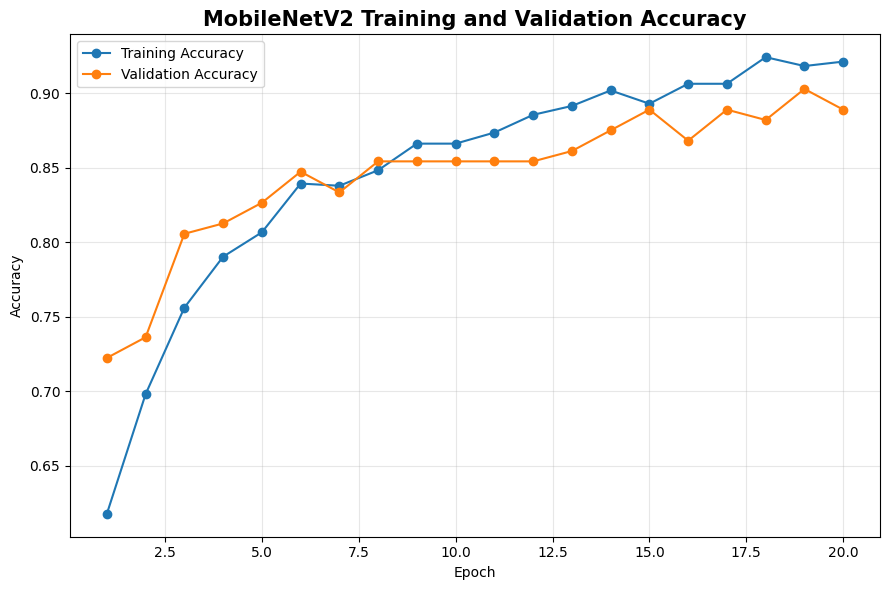

Saved: /content/outputs/plots/initial_accuracy.png


In [63]:
# ============================================================
# GRAPH 1 — ACCURACY
# ============================================================

plot_training_metric(

    history=history_initial,

    metric="accuracy",

    validation_metric="val_accuracy",

    title="MobileNetV2 Training and Validation Accuracy",

    ylabel="Accuracy",

    save_filename="initial_accuracy.png"
)

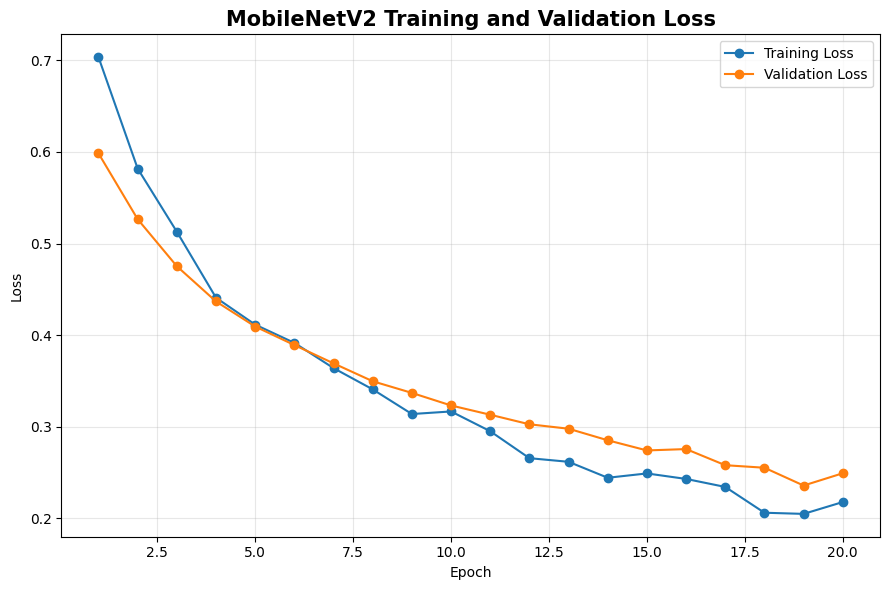

Saved: /content/outputs/plots/initial_loss.png


In [64]:
# ============================================================
# GRAPH 2 — LOSS
# ============================================================

plot_training_metric(

    history=history_initial,

    metric="loss",

    validation_metric="val_loss",

    title="MobileNetV2 Training and Validation Loss",

    ylabel="Loss",

    save_filename="initial_loss.png"
)

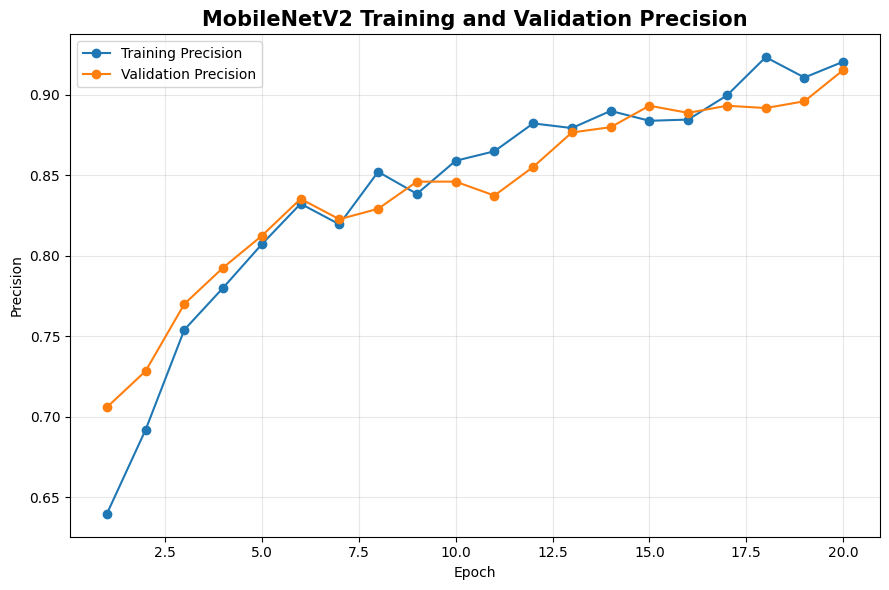

Saved: /content/outputs/plots/initial_precision.png


In [65]:
# ============================================================
# GRAPH 3 — PRECISION
# ============================================================

plot_training_metric(

    history=history_initial,

    metric="precision",

    validation_metric="val_precision",

    title="MobileNetV2 Training and Validation Precision",

    ylabel="Precision",

    save_filename="initial_precision.png"
)

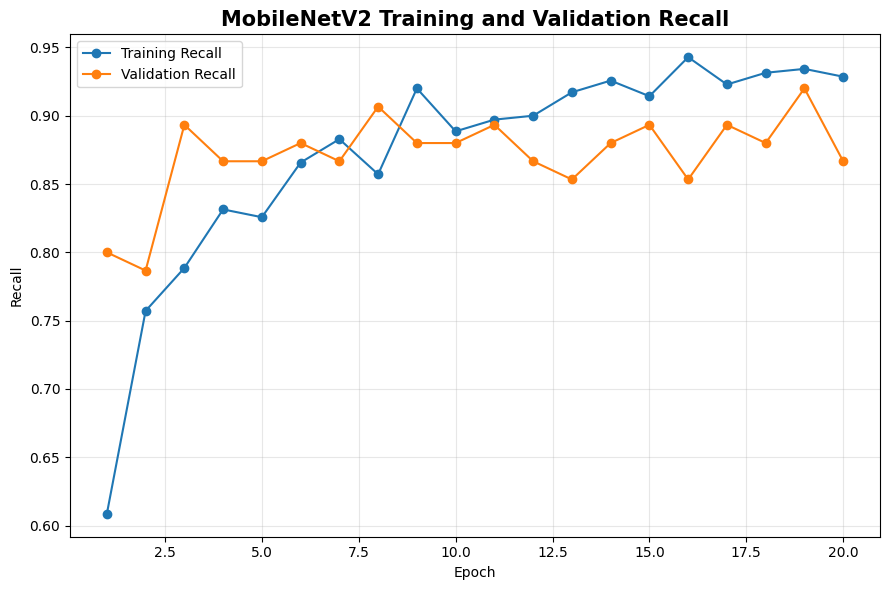

Saved: /content/outputs/plots/initial_recall.png


In [66]:
# ============================================================
# GRAPH 4 — RECALL
# ============================================================

plot_training_metric(

    history=history_initial,

    metric="recall",

    validation_metric="val_recall",

    title="MobileNetV2 Training and Validation Recall",

    ylabel="Recall",

    save_filename="initial_recall.png"
)

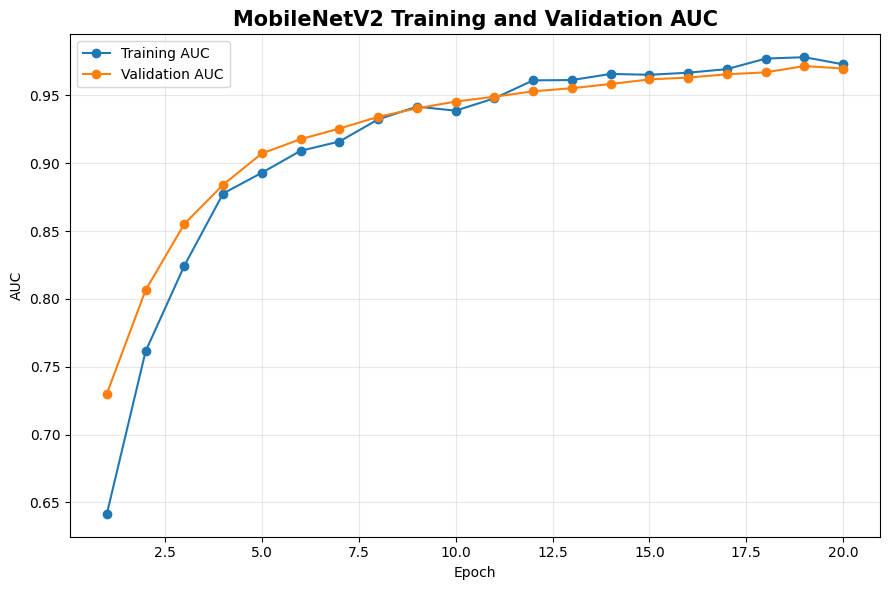

Saved: /content/outputs/plots/initial_auc.png


In [67]:
# ============================================================
# GRAPH 5 — AUC
# ============================================================

plot_training_metric(

    history=history_initial,

    metric="auc",

    validation_metric="val_auc",

    title="MobileNetV2 Training and Validation AUC",

    ylabel="AUC",

    save_filename="initial_auc.png"
)

In [68]:
# ============================================================
# SECTION 16.1 — BEST INITIAL EPOCH
# ============================================================

best_initial_epoch_index = int(
    np.argmin(
        history_initial.history[
            "val_loss"
        ]
    )
)


best_initial_epoch = (
    best_initial_epoch_index + 1
)


best_initial_val_loss = (
    history_initial.history[
        "val_loss"
    ][best_initial_epoch_index]
)


best_initial_val_accuracy = (
    history_initial.history[
        "val_accuracy"
    ][best_initial_epoch_index]
)


print("=" * 60)
print("BEST INITIAL TRAINING EPOCH")
print("=" * 60)


print(
    "Best epoch:",
    best_initial_epoch
)


print(
    f"Validation loss:"
    f" {best_initial_val_loss:.4f}"
)


print(
    f"Validation accuracy:"
    f" {best_initial_val_accuracy:.4f}"
)

BEST INITIAL TRAINING EPOCH
Best epoch: 19
Validation loss: 0.2358
Validation accuracy: 0.9028


In [69]:
# ============================================================
# SECTION 17 — LOAD BEST INITIAL MODEL
# ============================================================

print(
    "Loading:",
    INITIAL_MODEL_PATH
)


model = tf.keras.models.load_model(
    INITIAL_MODEL_PATH
)


print(
    "Best initial model loaded."
)

Loading: /content/models/mobilenetv2_best.keras
Best initial model loaded.


In [70]:
base_model = model.get_layer(
    "mobilenetv2_1.00_224"
)


print(
    "Base model:",
    base_model.name
)

Base model: mobilenetv2_1.00_224


In [71]:
# ============================================================
# ROBUSTLY FIND MOBILENETV2 INSIDE THE MODEL
# ============================================================

base_model = None


for layer in model.layers:

    if isinstance(
        layer,
        tf.keras.Model
    ):

        if "mobilenetv2" in layer.name.lower():

            base_model = layer

            break


if base_model is None:

    raise ValueError(
        "Unable to find the MobileNetV2 base model."
    )


print(
    "Detected base model:",
    base_model.name
)

Detected base model: mobilenetv2_1.00_224


In [72]:
# ============================================================
# SECTION 17.2 — ENABLE FINE-TUNING
# ============================================================

base_model.trainable = True


print(
    "Base model trainable:",
    base_model.trainable
)

Base model trainable: True


In [73]:
FINE_TUNE_LAYERS = 30

In [74]:
# ============================================================
# SECTION 17.3 — FREEZE EARLIER LAYERS
# ============================================================

FINE_TUNE_LAYERS = 30


fine_tune_start = (
    len(base_model.layers)
    -
    FINE_TUNE_LAYERS
)


for layer in base_model.layers[
    :fine_tune_start
]:

    layer.trainable = False

In [75]:
# ============================================================
# KEEP BATCH NORMALIZATION FROZEN
# ============================================================

for layer in base_model.layers:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):

        layer.trainable = False

In [76]:
# ============================================================
# SECTION 17.4 — CHECK TRAINABLE LAYERS
# ============================================================

trainable_base_layers = []


for index, layer in enumerate(
    base_model.layers
):

    if layer.trainable:

        trainable_base_layers.append(
            (
                index,
                layer.name,
                type(layer).__name__
            )
        )


print(
    "Trainable MobileNetV2 layers:",
    len(trainable_base_layers)
)


for layer_info in trainable_base_layers:

    print(
        layer_info
    )

Trainable MobileNetV2 layers: 19
(125, 'block_14_expand', 'Conv2D')
(127, 'block_14_expand_relu', 'ReLU')
(128, 'block_14_depthwise', 'DepthwiseConv2D')
(130, 'block_14_depthwise_relu', 'ReLU')
(131, 'block_14_project', 'Conv2D')
(133, 'block_14_add', 'Add')
(134, 'block_15_expand', 'Conv2D')
(136, 'block_15_expand_relu', 'ReLU')
(137, 'block_15_depthwise', 'DepthwiseConv2D')
(139, 'block_15_depthwise_relu', 'ReLU')
(140, 'block_15_project', 'Conv2D')
(142, 'block_15_add', 'Add')
(143, 'block_16_expand', 'Conv2D')
(145, 'block_16_expand_relu', 'ReLU')
(146, 'block_16_depthwise', 'DepthwiseConv2D')
(148, 'block_16_depthwise_relu', 'ReLU')
(149, 'block_16_project', 'Conv2D')
(151, 'Conv_1', 'Conv2D')
(153, 'out_relu', 'ReLU')


In [77]:
# ============================================================
# SECTION 17.5 — RECOMPILE FOR FINE-TUNING
# ============================================================

FINE_TUNING_LEARNING_RATE = 1e-5


fine_tune_optimizer = (
    tf.keras.optimizers.Adam(
        learning_rate=
        FINE_TUNING_LEARNING_RATE
    )
)


model.compile(

    optimizer=fine_tune_optimizer,

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)


print(
    "Fine-tuning model compiled."
)


print(
    "Learning rate:",
    FINE_TUNING_LEARNING_RATE
)

Fine-tuning model compiled.
Learning rate: 1e-05


In [78]:
# ============================================================
# SECTION 17.6 — PARAMETER COUNTS AFTER UNFREEZING
# ============================================================

fine_total_params = (
    model.count_params()
)


fine_trainable_params = sum(

    np.prod(variable.shape)

    for variable
    in model.trainable_weights
)


fine_non_trainable_params = sum(

    np.prod(variable.shape)

    for variable
    in model.non_trainable_weights
)


print("=" * 60)
print("FINE-TUNING PARAMETERS")
print("=" * 60)


print(
    f"Total:"
    f" {fine_total_params:,}"
)


print(
    f"Trainable:"
    f" {int(fine_trainable_params):,}"
)


print(
    f"Non-trainable:"
    f" {int(fine_non_trainable_params):,}"
)

FINE-TUNING PARAMETERS
Total: 2,422,081
Trainable: 1,674,817
Non-trainable: 747,264


In [79]:
# ============================================================
# SECTION 17.7 — FINE-TUNING CHECKPOINT
# ============================================================

FINETUNED_MODEL_PATH = (
    MODELS_DIR /
    "mobilenetv2_finetuned_best.keras"
)


fine_checkpoint_callback = (
    tf.keras.callbacks.ModelCheckpoint(

        filepath=str(
            FINETUNED_MODEL_PATH
        ),

        monitor="val_loss",

        mode="min",

        save_best_only=True,

        verbose=1
    )
)

In [80]:
fine_early_stopping_callback = (
    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=4,

        restore_best_weights=True,

        mode="min",

        verbose=1
    )
)

In [81]:
fine_reduce_lr_callback = (
    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=2,

        min_lr=1e-7,

        mode="min",

        verbose=1
    )
)

In [82]:
fine_tuning_callbacks = [

    fine_early_stopping_callback,

    fine_reduce_lr_callback,

    fine_checkpoint_callback

]

In [83]:
# ============================================================
# SECTION 17.8 — FINE-TUNING
# ============================================================

FINE_TUNING_EPOCHS = 12


print("=" * 60)
print("MOBILENETV2 FINE-TUNING")
print("=" * 60)


print(
    "Maximum epochs:",
    FINE_TUNING_EPOCHS
)


print(
    "Learning rate:",
    FINE_TUNING_LEARNING_RATE
)


fine_tuning_start_time = (
    time.time()
)


history_finetune = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=FINE_TUNING_EPOCHS,

    callbacks=
    fine_tuning_callbacks,

    class_weight=CLASS_WEIGHT,

    verbose=1
)


fine_tuning_end_time = (
    time.time()
)


fine_tuning_duration = (
    fine_tuning_end_time
    -
    fine_tuning_start_time
)


print("\n" + "=" * 60)
print("FINE-TUNING COMPLETE")
print("=" * 60)


print(
    f"Fine-tuning time:"
    f" {fine_tuning_duration:.2f}"
    f" seconds"
)


print(
    f"Fine-tuning time:"
    f" {fine_tuning_duration / 60:.2f}"
    f" minutes"
)

MOBILENETV2 FINE-TUNING
Maximum epochs: 12
Learning rate: 1e-05
Epoch 1/12
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9295 - auc: 0.9797 - loss: 0.1949 - precision: 0.9298 - recall: 0.9352
Epoch 1: val_loss improved from None to 0.21425, saving model to /content/models/mobilenetv2_finetuned_best.keras

Epoch 1: finished saving model to /content/models/mobilenetv2_finetuned_best.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - accuracy: 0.9271 - auc: 0.9796 - loss: 0.1920 - precision: 0.9312 - recall: 0.9286 - val_accuracy: 0.9167 - val_auc: 0.9776 - val_loss: 0.2143 - val_precision: 0.9315 - val_recall: 0.9067 - learning_rate: 1.0000e-05
Epoch 2/12
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9334 - auc: 0.9878 - loss: 0.1608 - precision: 0.9140 - recall: 0.9632
Epoch 2: val_loss improved from 0.21425 to 0.20830, saving model to /content/models/mobilenetv2_finetuned_best.keras

Epoch 2: finished saving model to /content/models/mobilenetv2_finetuned_best.keras
21/21

In [84]:
# ============================================================
# SECTION 17.9 — SAVE FINE-TUNING HISTORY
# ============================================================

fine_history_df = pd.DataFrame(
    history_finetune.history
)


fine_history_df.insert(
    0,
    "epoch",
    range(
        1,
        len(fine_history_df) + 1
    )
)


fine_history_path = (
    RESULTS_DIR /
    "fine_tuning_history.csv"
)


fine_history_df.to_csv(
    fine_history_path,
    index=False
)


display(
    fine_history_df
)


print(
    "Saved:",
    fine_history_path
)

,epoch,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,1,0.927083,0.979596,0.191983,0.931232,0.928571,0.916667,0.977584,0.214252,0.931507,0.906667,0.000010
1,2,0.934524,0.985799,0.161133,0.932203,0.942857,0.923611,0.981449,0.208297,0.970588,0.880000,0.000010
2,3,0.943452,0.989210,0.145757,0.943182,0.948571,0.923611,0.982512,0.225455,0.984848,0.866667,0.000010
3,4,0.937500,0.986957,0.147665,0.937500,0.942857,0.923611,0.983575,0.228965,0.984848,0.866667,0.000010
4,5,0.944940,0.988030,0.146025,0.933518,0.962857,0.930556,0.985604,0.202540,0.985075,0.880000,0.000005
5,6,0.959821,0.992067,0.119282,0.965418,0.957143,0.930556,0.986763,0.191870,0.985075,0.880000,0.000005
6,7,0.964286,0.994051,0.105988,0.965714,0.965714,0.930556,0.988116,0.194373,0.985075,0.880000,0.000005
7,8,0.964286,0.994170,0.109136,0.960452,0.971429,0.916667,0.986473,0.230343,0.984615,0.853333,0.000005
8,9,0.955357,0.991757,0.118593,0.962428,0.951429,0.930556,0.989662,0.179982,0.985075,0.880000,0.000002
9,10,0.965774,0.990896,0.118499,0.955432,0.980000,0.930556,0.989275,0.188303,0.985075,0.880000,0.000002


Saved: /content/results/fine_tuning_history.csv


In [85]:
# ============================================================
# SECTION 18 — COMBINE TRAINING HISTORIES
# ============================================================

def combine_histories(
    history1,
    history2
):

    combined = {}


    all_keys = set(
        history1.history.keys()
    ).intersection(
        history2.history.keys()
    )


    for key in all_keys:

        combined[key] = (

            list(
                history1.history[key]
            )

            +

            list(
                history2.history[key]
            )
        )


    return combined


combined_history = combine_histories(
    history_initial,
    history_finetune
)


fine_tuning_start_epoch = (
    len(
        history_initial.history[
            "loss"
        ]
    )
)


print(
    "Fine-tuning started after epoch:",
    fine_tuning_start_epoch
)

Fine-tuning started after epoch: 20


In [86]:
# ============================================================
# SECTION 18.1 — COMBINED GRAPH FUNCTION
# ============================================================

def plot_combined_metric(
    combined_history,
    metric,
    validation_metric,
    title,
    ylabel,
    save_filename
):

    train_values = (
        combined_history[
            metric
        ]
    )


    validation_values = (
        combined_history[
            validation_metric
        ]
    )


    epochs = range(
        1,
        len(train_values) + 1
    )


    plt.figure(
        figsize=(10, 6)
    )


    plt.plot(
        epochs,
        train_values,
        marker="o",
        label=f"Training {ylabel}"
    )


    plt.plot(
        epochs,
        validation_values,
        marker="o",
        label=f"Validation {ylabel}"
    )


    # Fine-tuning boundary
    plt.axvline(

        x=fine_tuning_start_epoch
          + 0.5,

        linestyle="--",

        label="Fine-Tuning Started"
    )


    plt.xlabel(
        "Epoch"
    )


    plt.ylabel(
        ylabel
    )


    plt.title(
        title,
        fontsize=15,
        fontweight="bold"
    )


    plt.legend()


    plt.grid(
        alpha=0.3
    )


    plt.tight_layout()


    save_path = (
        PLOTS_DIR /
        save_filename
    )


    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


    print(
        "Saved:",
        save_path
    )

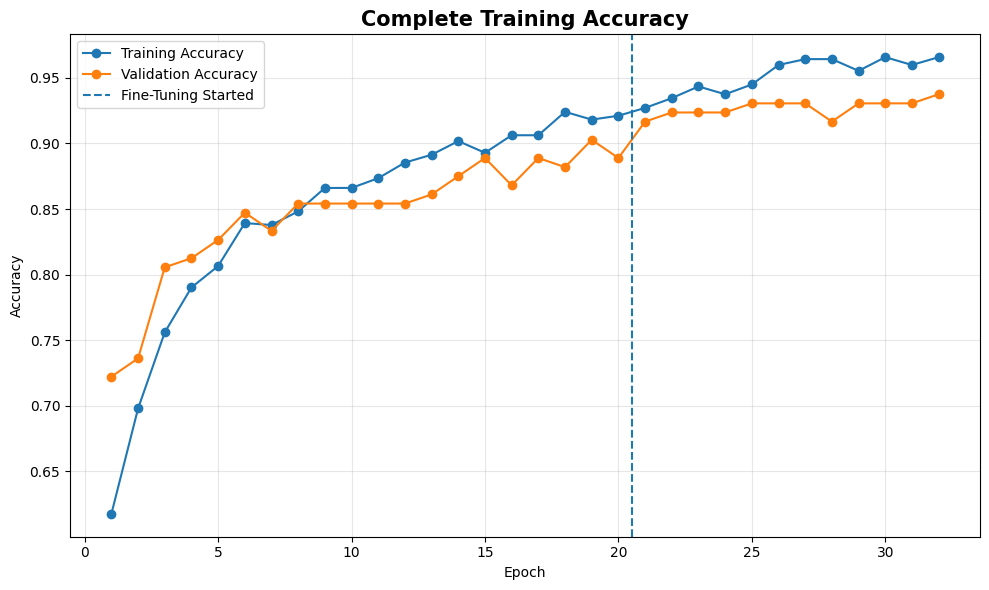

Saved: /content/outputs/plots/combined_accuracy.png


In [87]:
plot_combined_metric(

    combined_history,

    "accuracy",

    "val_accuracy",

    "Complete Training Accuracy",

    "Accuracy",

    "combined_accuracy.png"
)

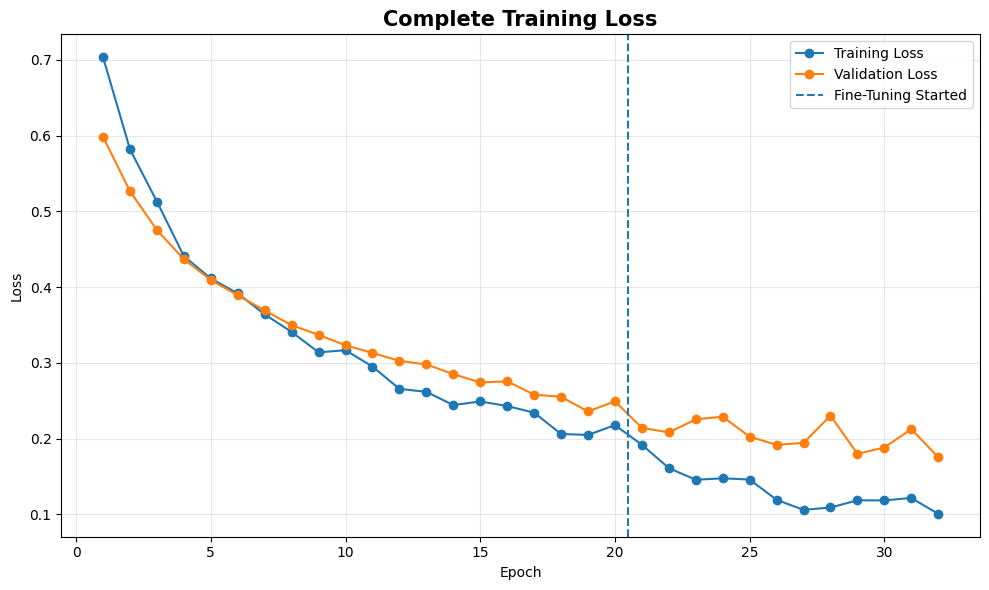

Saved: /content/outputs/plots/combined_loss.png


In [88]:
plot_combined_metric(

    combined_history,

    "loss",

    "val_loss",

    "Complete Training Loss",

    "Loss",

    "combined_loss.png"
)

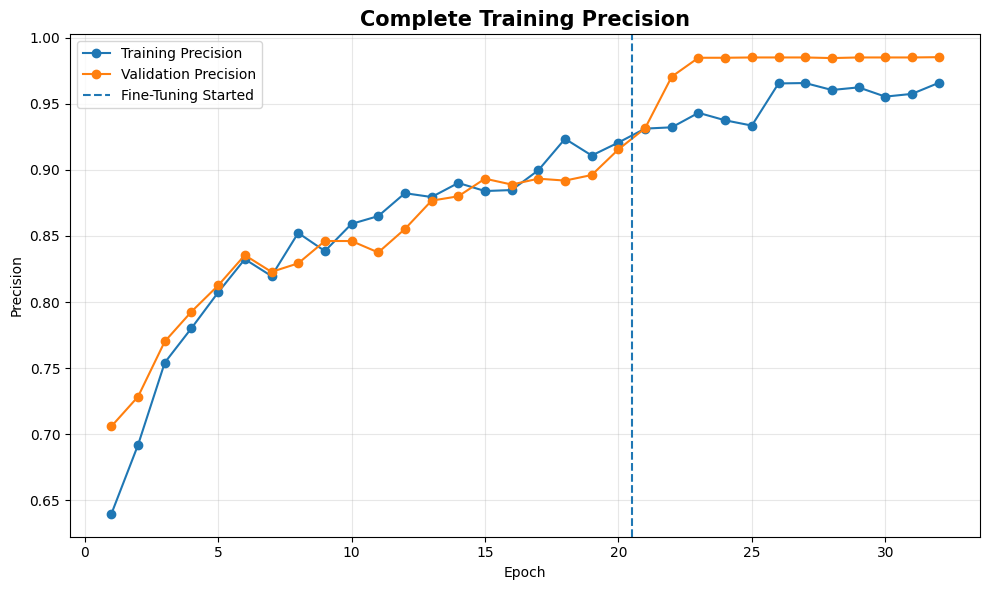

Saved: /content/outputs/plots/combined_precision.png


In [89]:
plot_combined_metric(

    combined_history,

    "precision",

    "val_precision",

    "Complete Training Precision",

    "Precision",

    "combined_precision.png"
)

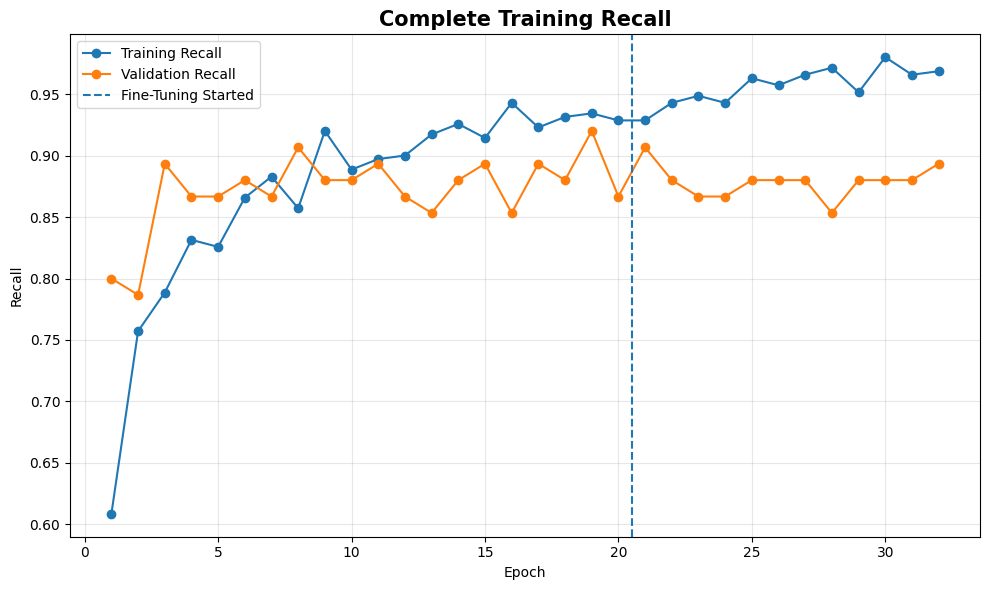

Saved: /content/outputs/plots/combined_recall.png


In [90]:
plot_combined_metric(

    combined_history,

    "recall",

    "val_recall",

    "Complete Training Recall",

    "Recall",

    "combined_recall.png"
)

In [91]:
# ============================================================
# SECTION 18.2 — SAVE COMPLETE HISTORY
# ============================================================

combined_history_df = pd.DataFrame(
    combined_history
)


combined_history_df.insert(
    0,
    "epoch",
    range(
        1,
        len(combined_history_df) + 1
    )
)


combined_history_df[
    "training_stage"
] = [

    "Transfer Learning"
    if epoch <= fine_tuning_start_epoch
    else "Fine-Tuning"

    for epoch
    in combined_history_df[
        "epoch"
    ]
]


display(
    combined_history_df
)

,epoch,auc,val_loss,val_accuracy,val_auc,val_recall,learning_rate,precision,loss,val_precision,recall,accuracy,training_stage
0,1,0.641500,0.598385,0.722222,0.730145,0.800000,0.000100,0.639640,0.703372,0.705882,0.608571,0.617560,Transfer Learning
1,2,0.761398,0.526514,0.736111,0.806473,0.786667,0.000100,0.691906,0.581771,0.728395,0.757143,0.697917,Transfer Learning
2,3,0.824472,0.475206,0.805556,0.855266,0.893333,0.000100,0.754098,0.512848,0.770115,0.788571,0.755952,Transfer Learning
3,4,0.877680,0.436750,0.812500,0.884155,0.866667,0.000100,0.780161,0.440808,0.792683,0.831429,0.790179,Transfer Learning
4,5,0.893021,0.409389,0.826389,0.907246,0.866667,0.000100,0.807263,0.411458,0.812500,0.825714,0.806548,Transfer Learning
5,6,0.909184,0.389171,0.847222,0.917778,0.880000,0.000100,0.832418,0.391554,0.835443,0.865714,0.839286,Transfer Learning
6,7,0.916034,0.369190,0.833333,0.925604,0.866667,0.000100,0.819629,0.363998,0.822785,0.882857,0.837798,Transfer Learning
7,8,0.932347,0.349665,0.854167,0.934203,0.906667,0.000100,0.852273,0.340794,0.829268,0.857143,0.848214,Transfer Learning
8,9,0.941744,0.336931,0.854167,0.940483,0.880000,0.000100,0.838542,0.313881,0.846154,0.920000,0.866071,Transfer Learning
9,10,0.938784,0.323229,0.854167,0.945507,0.880000,0.000100,0.859116,0.316692,0.846154,0.888571,0.866071,Transfer Learning


In [92]:
# ============================================================
# LOAD BEST FINE-TUNED MODEL
# ============================================================

final_model = (
    tf.keras.models.load_model(
        FINETUNED_MODEL_PATH
    )
)


print(
    "Best fine-tuned model loaded:"
)


print(
    FINETUNED_MODEL_PATH
)

Best fine-tuned model loaded:
/content/models/mobilenetv2_finetuned_best.keras


In [93]:
# ============================================================
# SECTION 25 — VALIDATION PREDICTIONS FOR THRESHOLD SELECTION
# ============================================================

print("=" * 60)
print("VALIDATION PREDICTIONS")
print("=" * 60)

validation_probabilities = final_model.predict(
    validation_dataset,
    verbose=1
).ravel()


validation_true = (
    validation_df["label_id"]
    .astype(int)
    .to_numpy()
)


print(
    "Validation labels:",
    validation_true.shape
)

print(
    "Validation probabilities:",
    validation_probabilities.shape
)

VALIDATION PREDICTIONS
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 801ms/step
Validation labels: (144,)
Validation probabilities: (144,)


In [94]:
# ============================================================
# SECTION 25.1 — CHECK VALIDATION PROBABILITIES
# ============================================================

print(
    "Minimum predicted probability:",
    validation_probabilities.min()
)

print(
    "Maximum predicted probability:",
    validation_probabilities.max()
)

print(
    "Mean predicted probability:",
    validation_probabilities.mean()
)


print(
    "\nFirst 10 probabilities:"
)

print(
    validation_probabilities[:10]
)

Minimum predicted probability: 1.1116804e-06
Maximum predicted probability: 0.9996126
Mean predicted probability: 0.4539624

First 10 probabilities:
[0.9982469  0.664543   0.98916185 0.32919538 0.9054285  0.9988715
 0.8609343  0.84207875 0.00560217 0.20319268]


In [95]:
# ============================================================
# SECTION 25.1 — CHECK VALIDATION PROBABILITIES
# ============================================================

print(
    "Minimum predicted probability:",
    validation_probabilities.min()
)

print(
    "Maximum predicted probability:",
    validation_probabilities.max()
)

print(
    "Mean predicted probability:",
    validation_probabilities.mean()
)


print(
    "\nFirst 10 probabilities:"
)

print(
    validation_probabilities[:10]
)

Minimum predicted probability: 1.1116804e-06
Maximum predicted probability: 0.9996126
Mean predicted probability: 0.4539624

First 10 probabilities:
[0.9982469  0.664543   0.98916185 0.32919538 0.9054285  0.9988715
 0.8609343  0.84207875 0.00560217 0.20319268]


In [96]:
# ============================================================
# SECTION 25.2 — THRESHOLD ANALYSIS
# ============================================================

threshold_values = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]


threshold_results = []


for threshold in threshold_values:

    predictions = (
        validation_probabilities
        >= threshold
    ).astype(int)


    accuracy = accuracy_score(
        validation_true,
        predictions
    )


    precision = precision_score(
        validation_true,
        predictions,
        zero_division=0
    )


    recall = recall_score(
        validation_true,
        predictions,
        zero_division=0
    )


    f1 = f1_score(
        validation_true,
        predictions,
        zero_division=0
    )


    threshold_results.append(
        {
            "Threshold": threshold,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        }
    )


threshold_df = pd.DataFrame(
    threshold_results
)


display(
    threshold_df
)

,Threshold,Accuracy,Precision,Recall,F1
0,0.1,0.930556,0.901235,0.973333,0.935897
1,0.2,0.944444,0.935065,0.960000,0.947368
2,0.3,0.944444,0.958904,0.933333,0.945946
3,0.4,0.937500,0.985294,0.893333,0.937063
4,0.5,0.937500,0.985294,0.893333,0.937063
5,0.6,0.930556,0.985075,0.880000,0.929577
6,0.7,0.909722,1.000000,0.826667,0.905109
7,0.8,0.881944,1.000000,0.773333,0.872180
8,0.9,0.750000,1.000000,0.520000,0.684211


In [97]:
# ============================================================
# SECTION 25.3 — SAVE THRESHOLD TABLE
# ============================================================

threshold_analysis_path = (
    RESULTS_DIR /
    "threshold_analysis.csv"
)


threshold_df.to_csv(
    threshold_analysis_path,
    index=False
)


print(
    "Saved:",
    threshold_analysis_path
)

Saved: /content/results/threshold_analysis.csv


In [ ]:
# ============================================================
# SECTION 25.4 — THRESHOLD VS F1
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o"
)


plt.title(
    "Validation Threshold vs F1-score",
    fontsize=15,
    fontweight="bold"
)


plt.xlabel(
    "Classification Threshold"
)


plt.ylabel(
    "F1-score"
)


plt.xticks(
    threshold_values
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


threshold_f1_path = (
    PLOTS_DIR /
    "threshold_vs_f1.png"
)


plt.savefig(
    threshold_f1_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

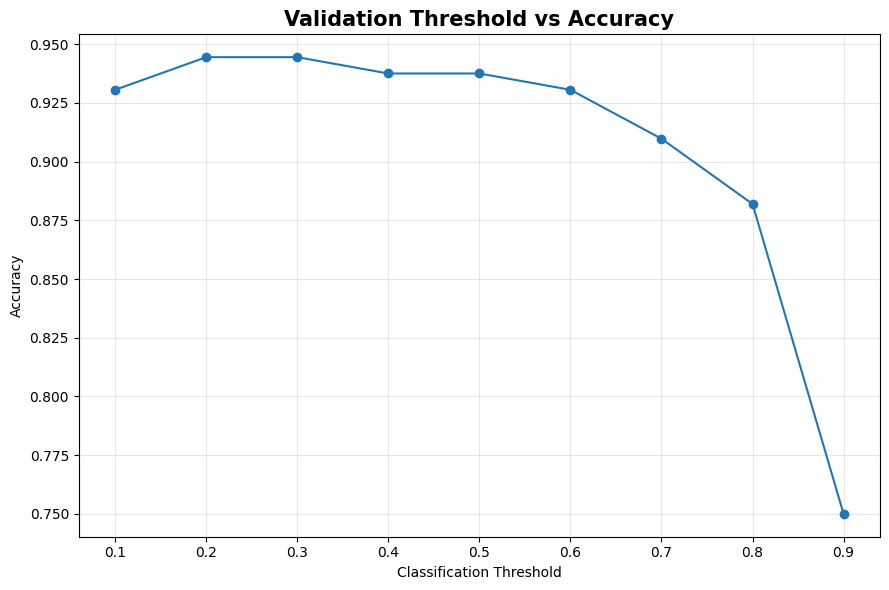

In [98]:
# ============================================================
# SECTION 25.5 — THRESHOLD VS ACCURACY
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    threshold_df["Threshold"],
    threshold_df["Accuracy"],
    marker="o"
)


plt.title(
    "Validation Threshold vs Accuracy",
    fontsize=15,
    fontweight="bold"
)


plt.xlabel(
    "Classification Threshold"
)


plt.ylabel(
    "Accuracy"
)


plt.xticks(
    threshold_values
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


threshold_accuracy_path = (
    PLOTS_DIR /
    "threshold_vs_accuracy.png"
)


plt.savefig(
    threshold_accuracy_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [99]:
# ============================================================
# SECTION 25.6 — SELECT BEST VALIDATION THRESHOLD
# ============================================================

best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]


SELECTED_THRESHOLD = float(
    best_threshold_row["Threshold"]
)


print("=" * 60)
print("SELECTED CLASSIFICATION THRESHOLD")
print("=" * 60)


print(
    f"Threshold:"
    f" {SELECTED_THRESHOLD:.2f}"
)


print(
    f"Validation Accuracy:"
    f" {best_threshold_row['Accuracy']:.4f}"
)


print(
    f"Validation Precision:"
    f" {best_threshold_row['Precision']:.4f}"
)


print(
    f"Validation Recall:"
    f" {best_threshold_row['Recall']:.4f}"
)


print(
    f"Validation F1:"
    f" {best_threshold_row['F1']:.4f}"
)

SELECTED CLASSIFICATION THRESHOLD
Threshold: 0.20
Validation Accuracy: 0.9444
Validation Precision: 0.9351
Validation Recall: 0.9600
Validation F1: 0.9474


In [100]:
# ============================================================
# SAVE SELECTED THRESHOLD
# ============================================================

selected_threshold_data = {
    "selected_threshold": SELECTED_THRESHOLD,
    "selection_dataset": "validation",
    "selection_metric": "F1-score"
}


with open(
    RESULTS_DIR /
    "selected_threshold.json",
    "w"
) as file:

    json.dump(
        selected_threshold_data,
        file,
        indent=4
    )


print(
    "Selected threshold saved."
)

Selected threshold saved.


In [101]:
# ============================================================
# SECTION 19 — FINAL TEST PREDICTIONS
# ============================================================

print("=" * 60)
print("FINAL UNSEEN TEST EVALUATION")
print("=" * 60)


test_probabilities = final_model.predict(
    test_dataset,
    verbose=1
).ravel()


y_true = (
    test_df["label_id"]
    .astype(int)
    .to_numpy()
)


y_probability = (
    test_probabilities
)


y_pred = (
    y_probability
    >= SELECTED_THRESHOLD
).astype(int)


print(
    "Test labels:",
    y_true.shape
)

print(
    "Test probabilities:",
    y_probability.shape
)

print(
    "Test predictions:",
    y_pred.shape
)

FINAL UNSEEN TEST EVALUATION
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 319ms/step
Test labels: (145,)
Test probabilities: (145,)
Test predictions: (145,)


In [102]:
# ============================================================
# SECTION 19.1 — FINAL TEST METRICS
# ============================================================

test_accuracy = accuracy_score(
    y_true,
    y_pred
)


test_precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)


test_recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)


test_f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)


test_roc_auc = roc_auc_score(
    y_true,
    y_probability
)


test_average_precision = (
    average_precision_score(
        y_true,
        y_probability
    )
)


print("=" * 60)
print("FINAL TEST PERFORMANCE")
print("=" * 60)


print(
    f"Selected Threshold : "
    f"{SELECTED_THRESHOLD:.2f}"
)


print(
    f"Accuracy           : "
    f"{test_accuracy:.4f}"
)


print(
    f"Precision          : "
    f"{test_precision:.4f}"
)


print(
    f"Recall             : "
    f"{test_recall:.4f}"
)


print(
    f"F1-score           : "
    f"{test_f1:.4f}"
)


print(
    f"ROC-AUC            : "
    f"{test_roc_auc:.4f}"
)


print(
    f"Average Precision  : "
    f"{test_average_precision:.4f}"
)

FINAL TEST PERFORMANCE
Selected Threshold : 0.20
Accuracy           : 0.9310
Precision          : 0.9114
Recall             : 0.9600
F1-score           : 0.9351
ROC-AUC            : 0.9661
Average Precision  : 0.9583


In [103]:
# ============================================================
# SECTION 19.2 — TEST LOSS
# ============================================================

test_evaluation = final_model.evaluate(
    test_dataset,
    verbose=1,
    return_dict=True
)


print(
    "\nModel.evaluate results:"
)


for metric_name, metric_value in (
    test_evaluation.items()
):

    print(
        f"{metric_name}: "
        f"{metric_value:.4f}"
    )


test_loss = float(
    test_evaluation["loss"]
)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.9034 - auc: 0.9659 - loss: 0.2392 - precision: 0.9296 - recall: 0.8800

Model.evaluate results:
accuracy: 0.9034
auc: 0.9659
loss: 0.2392
precision: 0.9296
recall: 0.8800


In [104]:
SELECTED_THRESHOLD

0.2

In [105]:
# ============================================================
# SECTION 19.3 — SAVE FINAL TEST METRICS
# ============================================================

test_metrics = {

    "threshold":
        SELECTED_THRESHOLD,

    "test_loss":
        test_loss,

    "accuracy":
        test_accuracy,

    "precision":
        test_precision,

    "recall":
        test_recall,

    "f1_score":
        test_f1,

    "roc_auc":
        test_roc_auc,

    "average_precision":
        test_average_precision
}


with open(
    RESULTS_DIR /
    "test_metrics.json",
    "w"
) as file:

    json.dump(
        {
            key: float(value)
            for key, value
            in test_metrics.items()
        },
        file,
        indent=4
    )


print(
    "Final test metrics saved."
)

Final test metrics saved.


In [106]:
# ============================================================
# SECTION 20 — TEST PREDICTION TABLE
# ============================================================

test_predictions_df = (
    test_df.copy()
)


test_predictions_df[
    "actual_label"
] = np.where(
    y_true == 1,
    "FAKE",
    "REAL"
)


test_predictions_df[
    "fake_probability"
] = y_probability


test_predictions_df[
    "predicted_label_id"
] = y_pred


test_predictions_df[
    "predicted_label"
] = np.where(
    y_pred == 1,
    "FAKE",
    "REAL"
)


test_predictions_df[
    "correct"
] = (
    y_true == y_pred
)


display(
    test_predictions_df.head(10)
)

,filepath,label,label_id,width,height,image_hash,actual_label,fake_probability,predicted_label_id,predicted_label,correct
0,/content/dataset_extracted/image_dataset/Real/...,REAL,0,630,355,1f89f40bd69bc0e877cca58df8498b7221b9e7ce0ac9bd...,REAL,0.269422,1,FAKE,False
1,/content/dataset_extracted/image_dataset/Fake/...,FAKE,1,151,168,8a0b6879a7b7bb9a1be52b9cc0541d244225be77ad41af...,FAKE,0.873092,1,FAKE,True
2,/content/dataset_extracted/image_dataset/Fake/...,FAKE,1,155,173,fb6e2f24c816ec2ca4949317b07b4991858cffcbcb53fb...,FAKE,0.925162,1,FAKE,True
3,/content/dataset_extracted/image_dataset/Real/...,REAL,0,550,310,10d01f35c25ce486de58d837a081dd572d24e7ba4cb856...,REAL,0.000228,0,REAL,True
4,/content/dataset_extracted/image_dataset/Real/...,REAL,0,630,355,f4afa81a8e9e6a6d94262afe39aa62154312c9264f586f...,REAL,0.001919,0,REAL,True
5,/content/dataset_extracted/image_dataset/Fake/...,FAKE,1,155,171,f4dc1317d27d8f8c11d8df09c3ae21083de9ae59d7b253...,FAKE,0.791450,1,FAKE,True
6,/content/dataset_extracted/image_dataset/Real/...,REAL,0,630,355,843b8640d99a9e184d0801a62d9fcb695823ea8abdebaa...,REAL,0.000021,0,REAL,True
7,/content/dataset_extracted/image_dataset/Real/...,REAL,0,1080,608,e7d250ab51b0e67da80b5316bbebd27ad0cd5eacb63555...,REAL,0.003729,0,REAL,True
8,/content/dataset_extracted/image_dataset/Fake/...,FAKE,1,211,165,c46abb1f483c4ed192685ed0276f0497e40647b4d46ff2...,FAKE,0.987172,1,FAKE,True
9,/content/dataset_extracted/image_dataset/Real/...,REAL,0,550,310,03d1a2238c12fd9a5a91c75e3bcdd996b167ac81ed686e...,REAL,0.000010,0,REAL,True


In [107]:
test_predictions_df.to_csv(
    RESULTS_DIR /
    "test_predictions.csv",
    index=False
)

In [108]:
# ============================================================
# SECTION 26 — PREDICTION CONFIDENCE
# ============================================================

def calculate_confidence(
    probability,
    predicted_class
):

    if predicted_class == 1:

        return probability

    else:

        return 1.0 - probability


test_predictions_df[
    "confidence"
] = [

    calculate_confidence(
        probability,
        prediction
    )

    for probability, prediction
    in zip(
        y_probability,
        y_pred
    )
]


test_predictions_df[
    "confidence_percent"
] = (
    test_predictions_df[
        "confidence"
    ]
    * 100
)


display(
    test_predictions_df[
        [
            "filepath",
            "actual_label",
            "predicted_label",
            "fake_probability",
            "confidence_percent",
            "correct"
        ]
    ].head(10)
)

,filepath,actual_label,predicted_label,fake_probability,confidence_percent,correct
0,/content/dataset_extracted/image_dataset/Real/...,REAL,FAKE,0.269422,26.942196,False
1,/content/dataset_extracted/image_dataset/Fake/...,FAKE,FAKE,0.873092,87.309174,True
2,/content/dataset_extracted/image_dataset/Fake/...,FAKE,FAKE,0.925162,92.516212,True
3,/content/dataset_extracted/image_dataset/Real/...,REAL,REAL,0.000228,99.977234,True
4,/content/dataset_extracted/image_dataset/Real/...,REAL,REAL,0.001919,99.808128,True
5,/content/dataset_extracted/image_dataset/Fake/...,FAKE,FAKE,0.791450,79.144958,True
6,/content/dataset_extracted/image_dataset/Real/...,REAL,REAL,0.000021,99.997887,True
7,/content/dataset_extracted/image_dataset/Real/...,REAL,REAL,0.003729,99.627113,True
8,/content/dataset_extracted/image_dataset/Fake/...,FAKE,FAKE,0.987172,98.717232,True
9,/content/dataset_extracted/image_dataset/Real/...,REAL,REAL,0.000010,99.998970,True


In [109]:
# ============================================================
# SECTION 21 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)


print(
    cm
)

[[63  7]
 [ 3 72]]


In [110]:
tn, fp, fn, tp = cm.ravel()


print(
    "True Negative :", tn
)

print(
    "False Positive:", fp
)

print(
    "False Negative:", fn
)

print(
    "True Positive :", tp
)

True Negative : 63
False Positive: 7
False Negative: 3
True Positive : 72


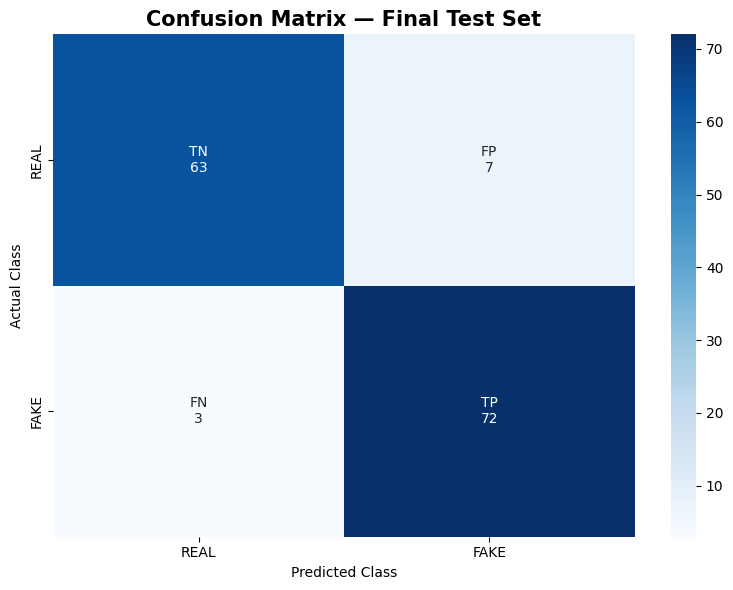

In [111]:
# ============================================================
# SECTION 21.1 — CONFUSION MATRIX VISUALIZATION
# ============================================================

annotation_labels = np.array(
    [
        [
            f"TN\n{tn}",
            f"FP\n{fp}"
        ],
        [
            f"FN\n{fn}",
            f"TP\n{tp}"
        ]
    ]
)


plt.figure(
    figsize=(8, 6)
)


sns.heatmap(
    cm,
    annot=annotation_labels,
    fmt="",
    cmap="Blues",
    xticklabels=[
        "REAL",
        "FAKE"
    ],
    yticklabels=[
        "REAL",
        "FAKE"
    ]
)


plt.title(
    "Confusion Matrix — Final Test Set",
    fontsize=15,
    fontweight="bold"
)


plt.xlabel(
    "Predicted Class"
)


plt.ylabel(
    "Actual Class"
)


plt.tight_layout()


confusion_matrix_path = (
    PLOTS_DIR /
    "confusion_matrix.png"
)


plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [112]:
# ============================================================
# SECTION 22 — CLASSIFICATION REPORT
# ============================================================

report_dict = classification_report(

    y_true,

    y_pred,

    target_names=[
        "REAL",
        "FAKE"
    ],

    output_dict=True,

    zero_division=0
)


report_df = pd.DataFrame(
    report_dict
).transpose()


display(
    report_df
)

,precision,recall,f1-score,support
REAL,0.954545,0.900000,0.926471,70.000000
FAKE,0.911392,0.960000,0.935065,75.000000
accuracy,0.931034,0.931034,0.931034,0.931034
macro avg,0.932969,0.930000,0.930768,145.000000
weighted avg,0.932225,0.931034,0.930916,145.000000


In [113]:
classification_report_path = (
    RESULTS_DIR /
    "classification_report.csv"
)


report_df.to_csv(
    classification_report_path
)


print(
    "Saved:",
    classification_report_path
)

Saved: /content/results/classification_report.csv


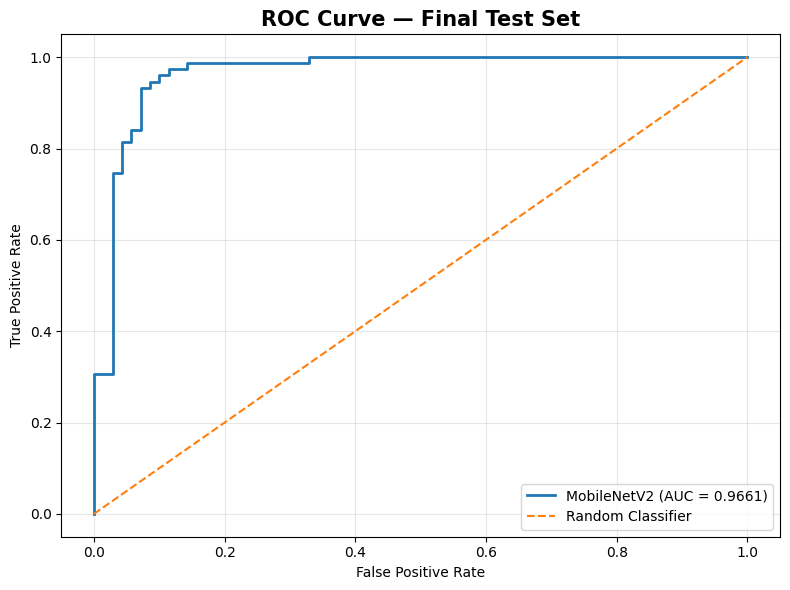

In [114]:
# ============================================================
# SECTION 23 — ROC CURVE
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    y_probability
)


roc_auc_value = roc_auc_score(
    y_true,
    y_probability
)


plt.figure(
    figsize=(8, 6)
)


plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"MobileNetV2 (AUC = {roc_auc_value:.4f})"
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve — Final Test Set",
    fontsize=15,
    fontweight="bold"
)


plt.legend(
    loc="lower right"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


roc_curve_path = (
    PLOTS_DIR /
    "roc_curve.png"
)


plt.savefig(
    roc_curve_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

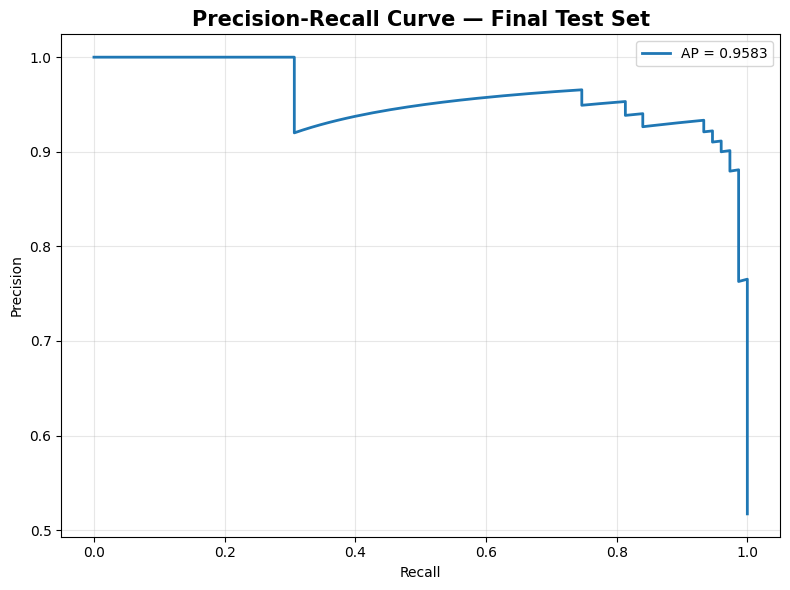

In [115]:
# ============================================================
# SECTION 24 — PRECISION-RECALL CURVE
# ============================================================

pr_precision, pr_recall, pr_thresholds = (
    precision_recall_curve(
        y_true,
        y_probability
    )
)


average_precision_value = (
    average_precision_score(
        y_true,
        y_probability
    )
)


plt.figure(
    figsize=(8, 6)
)


plt.plot(
    pr_recall,
    pr_precision,
    linewidth=2,
    label=(
        f"AP = "
        f"{average_precision_value:.4f}"
    )
)


plt.xlabel(
    "Recall"
)


plt.ylabel(
    "Precision"
)


plt.title(
    "Precision-Recall Curve — Final Test Set",
    fontsize=15,
    fontweight="bold"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


pr_curve_path = (
    PLOTS_DIR /
    "precision_recall_curve.png"
)


plt.savefig(
    pr_curve_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [116]:
# ============================================================
# SECTION 32 — MODEL PERFORMANCE SUMMARY
# ============================================================

performance_summary = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC-AUC",
            "Average Precision"
        ],

        "Score": [
            test_accuracy,
            test_precision,
            test_recall,
            test_f1,
            test_roc_auc,
            test_average_precision
        ]
    }
)


display(
    performance_summary
)

,Metric,Score
0,Accuracy,0.931034
1,Precision,0.911392
2,Recall,0.960000
3,F1-score,0.935065
4,ROC-AUC,0.966095
5,Average Precision,0.958287


In [117]:
test_predictions_df

,filepath,label,label_id,width,height,image_hash,actual_label,fake_probability,predicted_label_id,predicted_label,correct,confidence,confidence_percent
0,/content/dataset_extracted/image_dataset/Real/...,REAL,0,630,355,1f89f40bd69bc0e877cca58df8498b7221b9e7ce0ac9bd...,REAL,0.269422,1,FAKE,False,0.269422,26.942196
1,/content/dataset_extracted/image_dataset/Fake/...,FAKE,1,151,168,8a0b6879a7b7bb9a1be52b9cc0541d244225be77ad41af...,FAKE,0.873092,1,FAKE,True,0.873092,87.309174
2,/content/dataset_extracted/image_dataset/Fake/...,FAKE,1,155,173,fb6e2f24c816ec2ca4949317b07b4991858cffcbcb53fb...,FAKE,0.925162,1,FAKE,True,0.925162,92.516212
3,/content/dataset_extracted/image_dataset/Real/...,REAL,0,550,310,10d01f35c25ce486de58d837a081dd572d24e7ba4cb856...,REAL,0.000228,0,REAL,True,0.999772,99.977234
4,/content/dataset_extracted/image_dataset/Real/...,REAL,0,630,355,f4afa81a8e9e6a6d94262afe39aa62154312c9264f586f...,REAL,0.001919,0,REAL,True,0.998081,99.808128
...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,/content/dataset_extracted/image_dataset/Fake/...,FAKE,1,156,156,b2c0ad73f8e258fcfca3125edb90b67347ab0440ad08fa...,FAKE,0.409220,1,FAKE,True,0.409220,40.922039
141,/content/dataset_extracted/image_dataset/Real/...,REAL,0,600,400,72a167764f865d9682428f2e62fa16330f76cc6e64039b...,REAL,0.002880,0,REAL,True,0.997120,99.711967
142,/content/dataset_extracted/image_dataset/Real/...,REAL,0,630,355,52db39b9b04f45469209d4cc0a37005eb98a901c682341...,REAL,0.000119,0,REAL,True,0.999881,99.988106
143,/content/dataset_extracted/image_dataset/Fake/...,FAKE,1,128,155,6aa27d8f15b76c8e3ae11e749fd7c431c75704ac45942b...,FAKE,0.283789,1,FAKE,True,0.283789,28.378941


In [118]:
# ============================================================
# SECTION 27 — CATEGORIZE TEST PREDICTIONS
# ============================================================

# Correct REAL
correct_real_df = test_predictions_df[
    (test_predictions_df["actual_label"] == "REAL")
    &
    (test_predictions_df["predicted_label"] == "REAL")
].copy()


# Correct FAKE
correct_fake_df = test_predictions_df[
    (test_predictions_df["actual_label"] == "FAKE")
    &
    (test_predictions_df["predicted_label"] == "FAKE")
].copy()


# REAL wrongly predicted as FAKE
incorrect_real_df = test_predictions_df[
    (test_predictions_df["actual_label"] == "REAL")
    &
    (test_predictions_df["predicted_label"] == "FAKE")
].copy()


# FAKE wrongly predicted as REAL
incorrect_fake_df = test_predictions_df[
    (test_predictions_df["actual_label"] == "FAKE")
    &
    (test_predictions_df["predicted_label"] == "REAL")
].copy()


print("=" * 60)
print("PREDICTION CATEGORIES")
print("=" * 60)

print(
    "Correct REAL:",
    len(correct_real_df)
)

print(
    "Correct FAKE:",
    len(correct_fake_df)
)

print(
    "Incorrect REAL → FAKE:",
    len(incorrect_real_df)
)

print(
    "Incorrect FAKE → REAL:",
    len(incorrect_fake_df)
)

PREDICTION CATEGORIES
Correct REAL: 63
Correct FAKE: 72
Incorrect REAL → FAKE: 7
Incorrect FAKE → REAL: 3


In [121]:
# ============================================================
# SECTION 27.1 — DISPLAY SAMPLE PREDICTIONS
# ============================================================

def display_prediction_samples(
    dataframe,
    title,
    max_images=8,
    save_filename=None
):

    if len(dataframe) == 0:

        print(
            f"No images available for: {title}"
        )

        return


    sample_count = min(
        max_images,
        len(dataframe)
    )


    samples = dataframe.sample(
        n=sample_count,
        random_state=RANDOM_SEED
    )


    columns = 4

    rows = int(
        np.ceil(
            sample_count / columns
        )
    )


    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(
            16,
            4 * rows
        )
    )


    axes = np.array(
        axes
    ).reshape(-1)


    for ax, (_, row) in zip(
        axes,
        samples.iterrows()
    ):

        try:

            with Image.open(
                row["filepath"]
            ) as img:

                img = img.convert(
                    "RGB"
                )

                ax.imshow(
                    img
                )


            correctness = (
                "Correct"
                if row["correct"]
                else "Incorrect"
            )


            ax.set_title(

                f"Actual: "
                f"{row['actual_label']}\n"

                f"Predicted: "
                f"{row['predicted_label']}\n"

                f"FAKE Prob: "
                f"{row['fake_probability']:.3f}\n"

                f"{correctness}",

                fontsize=10
            )


            ax.axis(
                "off"
            )


        except Exception as e:

            ax.set_title(
                "Unable to display"
            )

            ax.axis(
                "off"
            )


    for ax in axes[
        sample_count:
    ]:

        ax.axis(
            "off"
        )


    fig.suptitle(
        title,
        fontsize=17,
        fontweight="bold"
    )


    plt.tight_layout()


    if save_filename is not None:

        save_path = (
            PLOTS_DIR /
            save_filename
        )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        print(
            "Saved:",
            save_path
        )


    plt.show()

Saved: /content/outputs/plots/correct_real_predictions.png


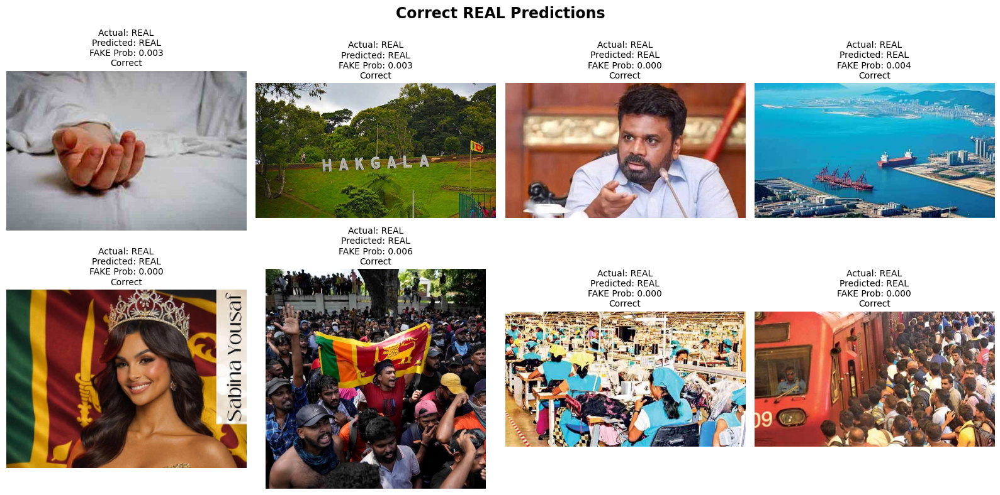

In [122]:
display_prediction_samples(

    correct_real_df,

    title="Correct REAL Predictions",

    max_images=8,

    save_filename=
    "correct_real_predictions.png"
)

Saved: /content/outputs/plots/incorrect_real_as_fake.png


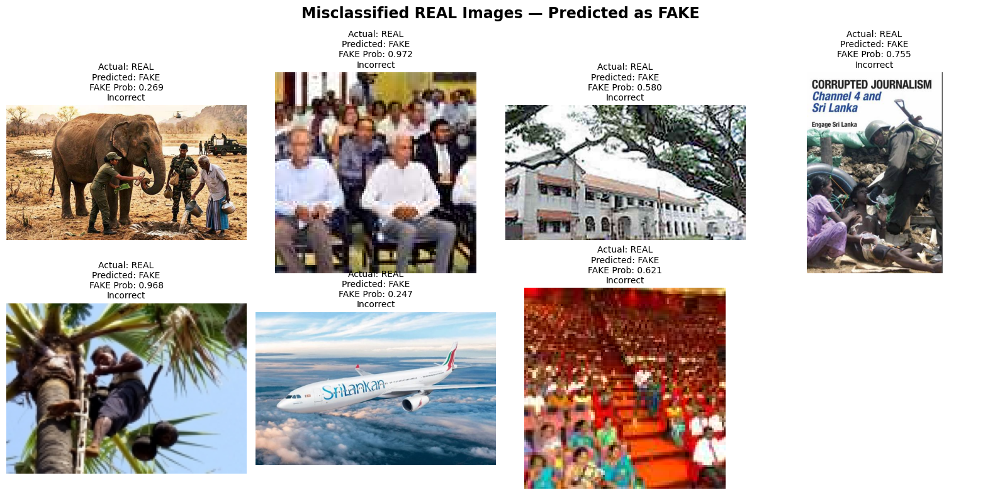

In [123]:
display_prediction_samples(

    incorrect_real_df,

    title="Misclassified REAL Images — Predicted as FAKE",

    max_images=8,

    save_filename=
    "incorrect_real_as_fake.png"
)

Saved: /content/outputs/plots/incorrect_fake_as_real.png


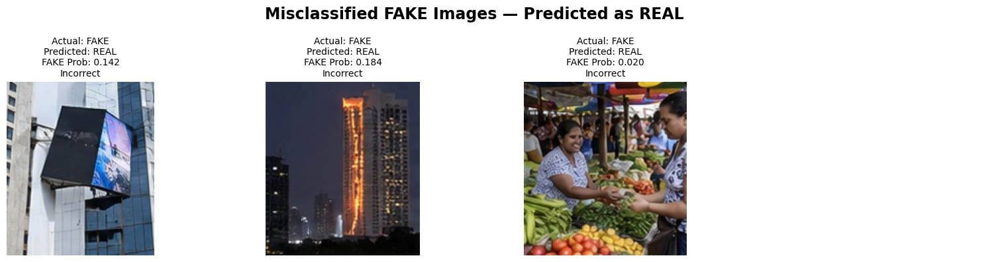

In [124]:
display_prediction_samples(

    incorrect_fake_df,

    title="Misclassified FAKE Images — Predicted as REAL",

    max_images=8,

    save_filename=
    "incorrect_fake_as_real.png"
)

In [125]:
# ============================================================
# SECTION 28 — ERROR ANALYSIS
# ============================================================

error_analysis_df = (
    test_predictions_df[
        test_predictions_df["correct"] == False
    ]
    .copy()
    .reset_index(drop=True)
)


print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)


print(
    "Total test images:",
    len(test_predictions_df)
)


print(
    "Total misclassified:",
    len(error_analysis_df)
)


print(
    "REAL → FAKE:",
    len(incorrect_real_df)
)


print(
    "FAKE → REAL:",
    len(incorrect_fake_df)
)

ERROR ANALYSIS
Total test images: 145
Total misclassified: 10
REAL → FAKE: 7
FAKE → REAL: 3


In [126]:
display(
    error_analysis_df[
        [
            "filepath",
            "actual_label",
            "predicted_label",
            "fake_probability",
            "confidence_percent"
        ]
    ]
)

,filepath,actual_label,predicted_label,fake_probability,confidence_percent
0,/content/dataset_extracted/image_dataset/Real/...,REAL,FAKE,0.269422,26.942196
1,/content/dataset_extracted/image_dataset/Fake/...,FAKE,REAL,0.142031,85.796890
2,/content/dataset_extracted/image_dataset/Real/...,REAL,FAKE,0.972250,97.224983
3,/content/dataset_extracted/image_dataset/Real/...,REAL,FAKE,0.754614,75.461388
4,/content/dataset_extracted/image_dataset/Real/...,REAL,FAKE,0.247016,24.701612
5,/content/dataset_extracted/image_dataset/Real/...,REAL,FAKE,0.968434,96.843376
6,/content/dataset_extracted/image_dataset/Real/...,REAL,FAKE,0.580094,58.009350
7,/content/dataset_extracted/image_dataset/Fake/...,FAKE,REAL,0.183938,81.606186
8,/content/dataset_extracted/image_dataset/Real/...,REAL,FAKE,0.621411,62.141113
9,/content/dataset_extracted/image_dataset/Fake/...,FAKE,REAL,0.019579,98.042091


In [127]:
# ============================================================
# SECTION 28.1 — SAVE ERROR ANALYSIS
# ============================================================

error_analysis_path = (
    RESULTS_DIR /
    "error_analysis.csv"
)


error_analysis_df.to_csv(
    error_analysis_path,
    index=False
)


print(
    "Saved:",
    error_analysis_path
)

Saved: /content/results/error_analysis.csv


In [128]:
# ============================================================
# SECTION 28.2 — ERROR CONFIDENCE ANALYSIS
# ============================================================

if len(error_analysis_df) > 0:

    error_analysis_sorted = (
        error_analysis_df.sort_values(
            "confidence",
            ascending=False
        )
    )


    display(
        error_analysis_sorted[
            [
                "filepath",
                "actual_label",
                "predicted_label",
                "fake_probability",
                "confidence_percent"
            ]
        ].head(20)
    )

else:

    print(
        "No misclassified test images."
    )

,filepath,actual_label,predicted_label,fake_probability,confidence_percent
9,/content/dataset_extracted/image_dataset/Fake/...,FAKE,REAL,0.019579,98.042091
2,/content/dataset_extracted/image_dataset/Real/...,REAL,FAKE,0.972250,97.224983
5,/content/dataset_extracted/image_dataset/Real/...,REAL,FAKE,0.968434,96.843376
1,/content/dataset_extracted/image_dataset/Fake/...,FAKE,REAL,0.142031,85.796890
7,/content/dataset_extracted/image_dataset/Fake/...,FAKE,REAL,0.183938,81.606186
3,/content/dataset_extracted/image_dataset/Real/...,REAL,FAKE,0.754614,75.461388
8,/content/dataset_extracted/image_dataset/Real/...,REAL,FAKE,0.621411,62.141113
6,/content/dataset_extracted/image_dataset/Real/...,REAL,FAKE,0.580094,58.009350
0,/content/dataset_extracted/image_dataset/Real/...,REAL,FAKE,0.269422,26.942196
4,/content/dataset_extracted/image_dataset/Real/...,REAL,FAKE,0.247016,24.701612


In [129]:
# ============================================================
# SECTION 29 — GRAD-CAM SETUP
# ============================================================

gradcam_base_model = None


for layer in final_model.layers:

    if isinstance(
        layer,
        tf.keras.Model
    ):

        if "mobilenetv2" in (
            layer.name.lower()
        ):

            gradcam_base_model = layer

            break


if gradcam_base_model is None:

    raise ValueError(
        "MobileNetV2 base model "
        "could not be found."
    )


print(
    "MobileNetV2 detected:",
    gradcam_base_model.name
)

MobileNetV2 detected: mobilenetv2_1.00_224


In [130]:
# ============================================================
# SECTION 29.1 — FIND FINAL CONVOLUTIONAL LAYER
# ============================================================

def find_last_conv_layer(
    model
):

    convolution_types = (
        tf.keras.layers.Conv2D,
        tf.keras.layers.DepthwiseConv2D,
        tf.keras.layers.SeparableConv2D
    )


    for layer in reversed(
        model.layers
    ):

        if isinstance(
            layer,
            convolution_types
        ):

            return layer


    raise ValueError(
        "No convolutional layer found."
    )


last_conv_layer = (
    find_last_conv_layer(
        gradcam_base_model
    )
)


LAST_CONV_LAYER_NAME = (
    last_conv_layer.name
)


print(
    "Automatically detected final "
    "convolutional layer:"
)

print(
    LAST_CONV_LAYER_NAME
)

Automatically detected final convolutional layer:
Conv_1


In [131]:
# ============================================================
# SECTION 29.2 — FEATURE MODEL
# ============================================================

gradcam_feature_model = (
    tf.keras.Model(

        inputs=
        gradcam_base_model.inputs,

        outputs=[
            last_conv_layer.output,
            gradcam_base_model.output
        ]
    )
)


print(
    "Grad-CAM feature model created."
)

Grad-CAM feature model created.


In [132]:
# ============================================================
# SECTION 29.3 — GET CLASSIFICATION HEAD
# ============================================================

gap_layer = final_model.get_layer(
    "global_average_pooling"
)


dropout1_layer = final_model.get_layer(
    "dropout_1"
)


dense_features_layer = final_model.get_layer(
    "dense_features"
)


dropout2_layer = final_model.get_layer(
    "dropout_2"
)


prediction_layer = final_model.get_layer(
    "prediction"
)


print(
    "Classification-head layers loaded."
)

Classification-head layers loaded.


In [133]:
# ============================================================
# SECTION 29.4 — GRAD-CAM IMAGE LOADER
# ============================================================

def load_image_for_gradcam(
    image_path
):

    with Image.open(
        image_path
    ) as img:

        original_image = (
            img.convert("RGB")
        )


    resized_image = (
        original_image.resize(
            IMAGE_SIZE
        )
    )


    image_array = np.array(
        resized_image,
        dtype=np.float32
    )


    image_batch = (
        np.expand_dims(
            image_array,
            axis=0
        )
    )


    return (
        original_image,
        image_batch
    )

In [134]:
# ============================================================
# SECTION 29.5 — MAKE GRAD-CAM HEATMAP
# ============================================================

def make_gradcam_heatmap(
    image_path,
    target_class=None
):

    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    original_image, image_batch = (
        load_image_for_gradcam(
            image_path
        )
    )


    image_tensor = tf.convert_to_tensor(
        image_batch,
        dtype=tf.float32
    )


    # --------------------------------------------------------
    # Augmentation layer in inference mode
    # No random transformations are applied.
    # --------------------------------------------------------

    augmentation_layer = (
        final_model.get_layer(
            "data_augmentation"
        )
    )


    model_input = augmentation_layer(
        image_tensor,
        training=False
    )


    # --------------------------------------------------------
    # MobileNetV2 preprocessing
    # --------------------------------------------------------

    preprocessed_input = (
        tf.keras.applications
        .mobilenet_v2
        .preprocess_input(
            model_input
        )
    )


    # --------------------------------------------------------
    # Gradient calculation
    # --------------------------------------------------------

    with tf.GradientTape() as tape:

        conv_outputs, features = (
            gradcam_feature_model(
                preprocessed_input,
                training=False
            )
        )


        # Classification head
        x = gap_layer(
            features
        )


        x = dropout1_layer(
            x,
            training=False
        )


        x = dense_features_layer(
            x
        )


        x = dropout2_layer(
            x,
            training=False
        )


        fake_probability = (
            prediction_layer(
                x
            )
        )


        # ----------------------------------------------------
        # Determine class to explain
        #
        # 0 = REAL
        # 1 = FAKE
        # ----------------------------------------------------

        predicted_class = int(
            fake_probability[
                0, 0
            ].numpy()
            >= SELECTED_THRESHOLD
        )


        if target_class is None:

            target_class = (
                predicted_class
            )


        if target_class == 1:

            target_score = (
                fake_probability[
                    :, 0
                ]
            )

        else:

            target_score = (
                1.0
                -
                fake_probability[
                    :, 0
                ]
            )


    gradients = tape.gradient(
        target_score,
        conv_outputs
    )


    if gradients is None:

        raise RuntimeError(
            "Unable to compute Grad-CAM gradients."
        )


    # --------------------------------------------------------
    # Global average pooling of gradients
    # --------------------------------------------------------

    pooled_gradients = (
        tf.reduce_mean(
            gradients,
            axis=(0, 1, 2)
        )
    )


    conv_outputs = (
        conv_outputs[0]
    )


    # Weight channels
    heatmap = tf.reduce_sum(

        conv_outputs
        *
        pooled_gradients,

        axis=-1
    )


    # Keep positive contribution
    heatmap = tf.maximum(
        heatmap,
        0
    )


    maximum = tf.reduce_max(
        heatmap
    )


    if float(maximum) > 0:

        heatmap = (
            heatmap
            /
            maximum
        )


    heatmap = heatmap.numpy()


    return {
        "original_image":
            original_image,

        "heatmap":
            heatmap,

        "fake_probability":
            float(
                fake_probability[
                    0, 0
                ].numpy()
            ),

        "predicted_class_id":
            predicted_class,

        "target_class_id":
            target_class
    }

In [135]:
# ============================================================
# SECTION 29.6 — CREATE GRAD-CAM OVERLAY
# ============================================================

def create_gradcam_overlay(
    original_image,
    heatmap,
    alpha=0.40
):

    # Resize heatmap to original image dimensions
    heatmap_uint8 = np.uint8(
        255 * heatmap
    )


    heatmap_image = Image.fromarray(
        heatmap_uint8
    )


    heatmap_image = (
        heatmap_image.resize(
            original_image.size,
            resample=Image.BILINEAR
        )
    )


    heatmap_array = (
        np.array(
            heatmap_image
        )
        /
        255.0
    )


    # Use Matplotlib's jet colormap
    colormap = plt.get_cmap(
        "jet"
    )


    colored_heatmap = (
        colormap(
            heatmap_array
        )[
            :, :, :3
        ]
    )


    original_array = (
        np.array(
            original_image
        )
        /
        255.0
    )


    overlay = (

        (1 - alpha)
        *
        original_array

        +

        alpha
        *
        colored_heatmap
    )


    overlay = np.clip(
        overlay,
        0,
        1
    )


    return (
        heatmap_array,
        overlay
    )

In [136]:
# ============================================================
# SECTION 29.7 — DISPLAY AND SAVE GRAD-CAM
# ============================================================

def display_gradcam(
    image_path,
    actual_label=None,
    target_class=None,
    save_filename=None
):

    result = make_gradcam_heatmap(
        image_path=image_path,
        target_class=target_class
    )


    original_image = (
        result[
            "original_image"
        ]
    )


    heatmap = (
        result[
            "heatmap"
        ]
    )


    fake_probability = (
        result[
            "fake_probability"
        ]
    )


    predicted_class_id = (
        result[
            "predicted_class_id"
        ]
    )


    predicted_label = (
        "FAKE"
        if predicted_class_id == 1
        else "REAL"
    )


    heatmap_resized, overlay = (
        create_gradcam_overlay(
            original_image,
            heatmap
        )
    )


    fig, axes = plt.subplots(
        1,
        3,
        figsize=(16, 5)
    )


    # Original
    axes[0].imshow(
        original_image
    )

    axes[0].set_title(
        "Original Image"
    )

    axes[0].axis(
        "off"
    )


    # Heatmap
    axes[1].imshow(
        heatmap_resized,
        cmap="jet"
    )

    axes[1].set_title(
        "Grad-CAM Heatmap"
    )

    axes[1].axis(
        "off"
    )


    # Overlay
    axes[2].imshow(
        overlay
    )

    axes[2].set_title(
        "Grad-CAM Overlay"
    )

    axes[2].axis(
        "off"
    )


    title = (
        f"Prediction: "
        f"{predicted_label}"
        f" | FAKE Probability: "
        f"{fake_probability:.4f}"
    )


    if actual_label is not None:

        title += (
            f" | Actual: "
            f"{actual_label}"
        )


    fig.suptitle(
        title,
        fontsize=14,
        fontweight="bold"
    )


    plt.tight_layout()


    if save_filename is not None:

        save_path = (
            GRADCAM_DIR /
            save_filename
        )


        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )


        print(
            "Saved:",
            save_path
        )


    plt.show()


    return result

Saved: /content/outputs/gradcam/gradcam_real_example.png


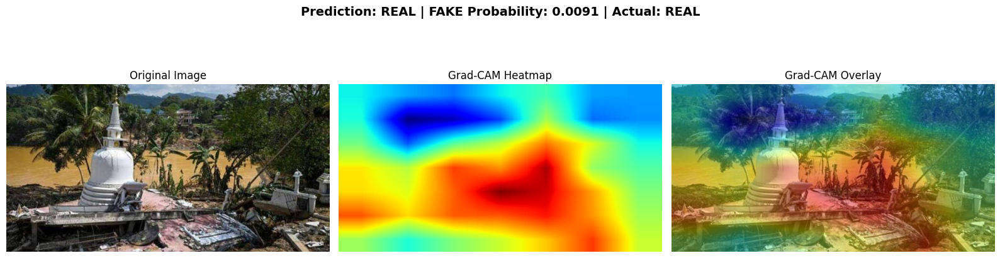

{'original_image': <PIL.Image.Image image mode=RGB size=738x384>,
 'heatmap': array([[0.36540884, 0.28805363, 0.24118598, 0.36190158, 0.43335664,
         0.28616   , 0.2750386 ],
        [0.38773635, 0.        , 0.0502796 , 0.19151418, 0.5538561 ,
         0.23168369, 0.2672681 ],
        [0.49187678, 0.21483317, 0.4598413 , 0.5829861 , 0.7853234 ,
         0.61840504, 0.37736234],
        [0.6635159 , 0.57577664, 0.8506573 , 0.754333  , 0.96630234,
         0.5344802 , 0.45149642],
        [0.6768808 , 0.62650263, 0.8126671 , 1.        , 0.93404263,
         0.73768556, 0.50910157],
        [0.82534605, 0.6808769 , 0.81612414, 0.82099867, 0.892657  ,
         0.75471383, 0.54990774],
        [0.5439129 , 0.38808906, 0.51308924, 0.5980427 , 0.69859946,
         0.8525503 , 0.59576684]], dtype=float32),
 'fake_probability': 0.009068186394870281,
 'predicted_class_id': 0,
 'target_class_id': 0}

In [137]:
# ============================================================
# SECTION 29.8 — REAL IMAGE GRAD-CAM
# ============================================================

real_gradcam_sample = (
    test_predictions_df[
        test_predictions_df[
            "actual_label"
        ] == "REAL"
    ]
    .sample(
        n=1,
        random_state=RANDOM_SEED
    )
    .iloc[0]
)


display_gradcam(

    image_path=
    real_gradcam_sample[
        "filepath"
    ],

    actual_label="REAL",

    save_filename=
    "gradcam_real_example.png"
)

Saved: /content/outputs/gradcam/gradcam_fake_example.png


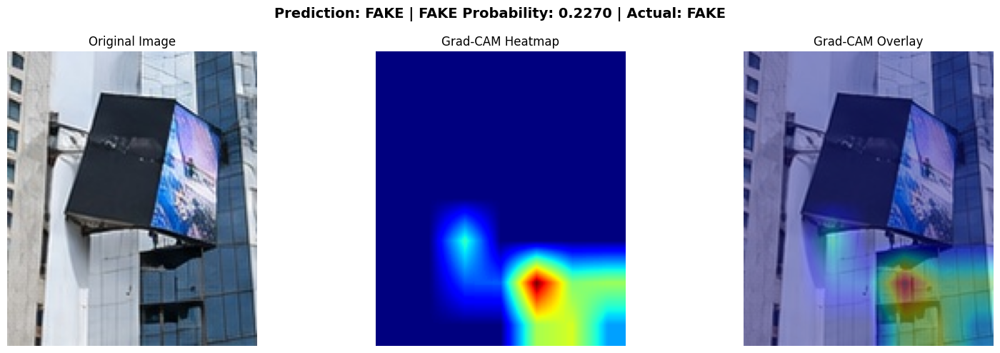

{'original_image': <PIL.Image.Image image mode=RGB size=139x164>,
 'heatmap': array([[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.41071916, 0.        , 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.20126835, 0.21165973, 1.        ,
         0.50122595, 0.5363409 ],
        [0.        , 0.        , 0.        , 0.        , 0.5482926 ,
         0.6032769 , 0.2805242 ]], dtype=float32),
 'fake_probability': 0.22702479362487793,
 'predicted_class_id': 1,
 'target_class_id': 1}

In [138]:
# ============================================================
# SECTION 29.9 — FAKE IMAGE GRAD-CAM
# ============================================================

fake_gradcam_sample = (
    test_predictions_df[
        test_predictions_df[
            "actual_label"
        ] == "FAKE"
    ]
    .sample(
        n=1,
        random_state=RANDOM_SEED
    )
    .iloc[0]
)


display_gradcam(

    image_path=
    fake_gradcam_sample[
        "filepath"
    ],

    actual_label="FAKE",

    save_filename=
    "gradcam_fake_example.png"
)


REAL → FAKE error: 1
Saved: /content/outputs/gradcam/error_real_to_fake_1.png


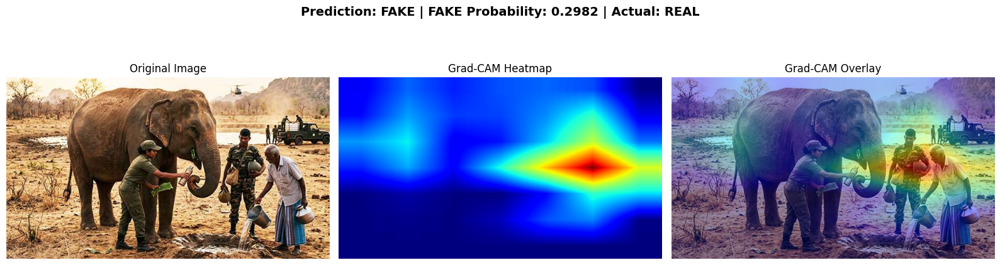


REAL → FAKE error: 2
Saved: /content/outputs/gradcam/error_real_to_fake_2.png


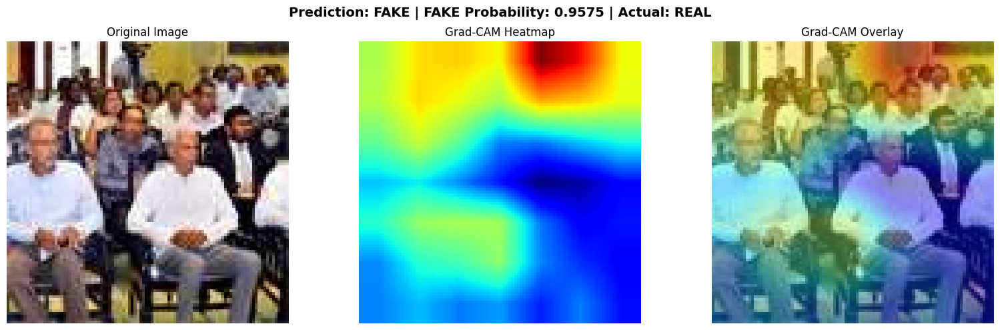


REAL → FAKE error: 3
Saved: /content/outputs/gradcam/error_real_to_fake_3.png


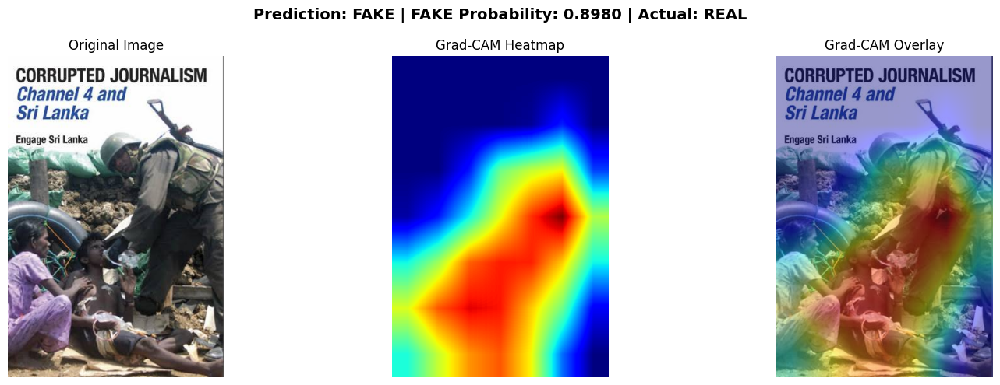


REAL → FAKE error: 4
Saved: /content/outputs/gradcam/error_real_to_fake_4.png


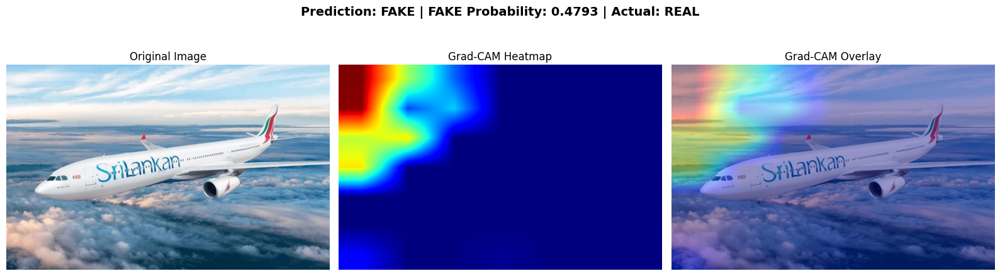

In [139]:
# ============================================================
# SECTION 31 — GRAD-CAM FOR MISCLASSIFIED IMAGES
# ============================================================

MAX_GRADCAM_ERRORS = 4


if len(incorrect_real_df) > 0:

    real_to_fake_samples = (
        incorrect_real_df.head(
            MAX_GRADCAM_ERRORS
        )
    )


    for number, (_, row) in enumerate(
        real_to_fake_samples.iterrows(),
        start=1
    ):

        print(
            "\nREAL → FAKE error:",
            number
        )


        display_gradcam(

            image_path=
            row["filepath"],

            actual_label=
            row["actual_label"],

            save_filename=(
                f"error_real_to_fake_"
                f"{number}.png"
            )
        )


else:

    print(
        "No REAL → FAKE "
        "misclassifications available."
    )


FAKE → REAL error: 1
Saved: /content/outputs/gradcam/error_fake_to_real_1.png


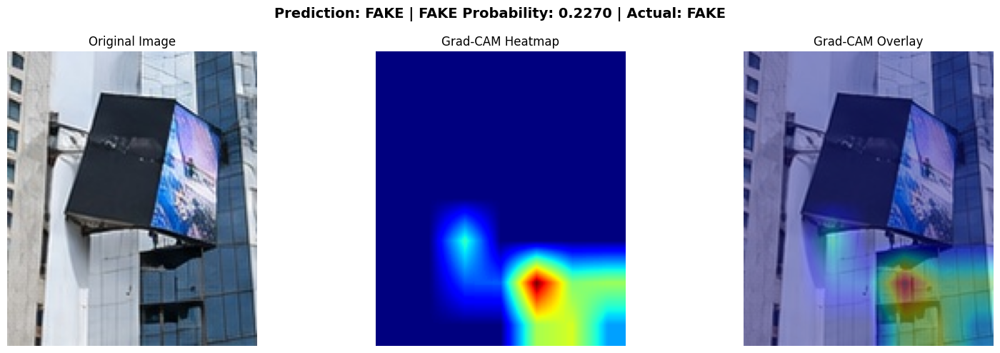


FAKE → REAL error: 2
Saved: /content/outputs/gradcam/error_fake_to_real_2.png


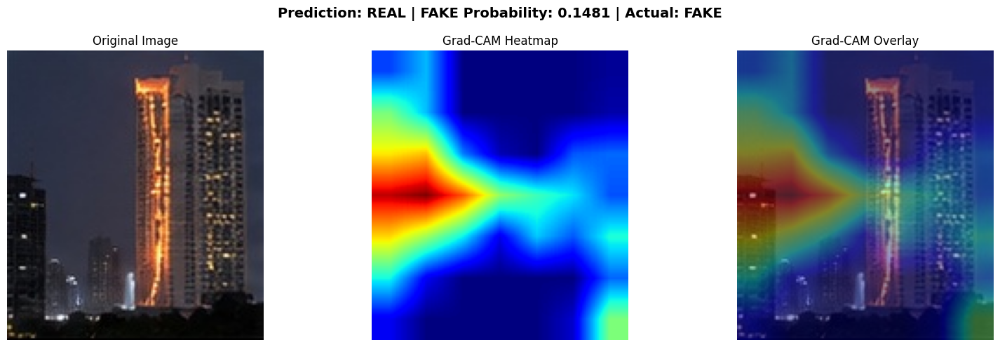


FAKE → REAL error: 3
Saved: /content/outputs/gradcam/error_fake_to_real_3.png


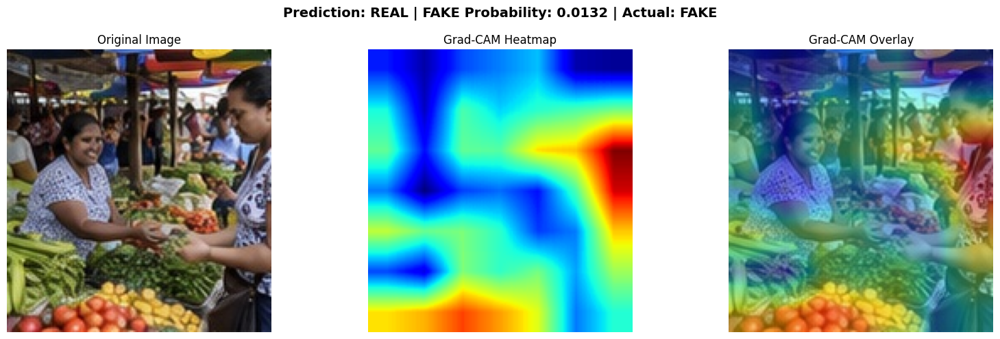

In [140]:
# ============================================================
# SECTION 31.1 — FALSE NEGATIVE GRAD-CAM
# ============================================================

if len(incorrect_fake_df) > 0:

    fake_to_real_samples = (
        incorrect_fake_df.head(
            MAX_GRADCAM_ERRORS
        )
    )


    for number, (_, row) in enumerate(
        fake_to_real_samples.iterrows(),
        start=1
    ):

        print(
            "\nFAKE → REAL error:",
            number
        )


        display_gradcam(

            image_path=
            row["filepath"],

            actual_label=
            row["actual_label"],

            save_filename=(
                f"error_fake_to_real_"
                f"{number}.png"
            )
        )


else:

    print(
        "No FAKE → REAL "
        "misclassifications available."
    )

In [141]:
# ============================================================
# SECTION 31.2 — GRAD-CAM ANALYSIS INDEX
# ============================================================

gradcam_analysis_records = []


# Correct/sample REAL
gradcam_analysis_records.append(
    {
        "filepath":
            real_gradcam_sample[
                "filepath"
            ],

        "actual_label":
            "REAL",

        "category":
            "REAL example"
    }
)


# Correct/sample FAKE
gradcam_analysis_records.append(
    {
        "filepath":
            fake_gradcam_sample[
                "filepath"
            ],

        "actual_label":
            "FAKE",

        "category":
            "FAKE example"
    }
)


for _, row in (
    incorrect_real_df.head(
        MAX_GRADCAM_ERRORS
    ).iterrows()
):

    gradcam_analysis_records.append(
        {
            "filepath":
                row["filepath"],

            "actual_label":
                row["actual_label"],

            "predicted_label":
                row["predicted_label"],

            "fake_probability":
                row["fake_probability"],

            "category":
                "REAL_to_FAKE_error"
        }
    )


for _, row in (
    incorrect_fake_df.head(
        MAX_GRADCAM_ERRORS
    ).iterrows()
):

    gradcam_analysis_records.append(
        {
            "filepath":
                row["filepath"],

            "actual_label":
                row["actual_label"],

            "predicted_label":
                row["predicted_label"],

            "fake_probability":
                row["fake_probability"],

            "category":
                "FAKE_to_REAL_error"
        }
    )


gradcam_analysis_df = (
    pd.DataFrame(
        gradcam_analysis_records
    )
)


display(
    gradcam_analysis_df
)

,filepath,actual_label,category,predicted_label,fake_probability
0,/content/dataset_extracted/image_dataset/Real/...,REAL,REAL example,NaN,NaN
1,/content/dataset_extracted/image_dataset/Fake/...,FAKE,FAKE example,NaN,NaN
2,/content/dataset_extracted/image_dataset/Real/...,REAL,REAL_to_FAKE_error,FAKE,0.269422
3,/content/dataset_extracted/image_dataset/Real/...,REAL,REAL_to_FAKE_error,FAKE,0.972250
4,/content/dataset_extracted/image_dataset/Real/...,REAL,REAL_to_FAKE_error,FAKE,0.754614
5,/content/dataset_extracted/image_dataset/Real/...,REAL,REAL_to_FAKE_error,FAKE,0.247016
6,/content/dataset_extracted/image_dataset/Fake/...,FAKE,FAKE_to_REAL_error,REAL,0.142031
7,/content/dataset_extracted/image_dataset/Fake/...,FAKE,FAKE_to_REAL_error,REAL,0.183938
8,/content/dataset_extracted/image_dataset/Fake/...,FAKE,FAKE_to_REAL_error,REAL,0.019579


In [142]:
# ============================================================
# SECTION 31.3 — LIST GRAD-CAM OUTPUTS
# ============================================================

gradcam_files = list(
    GRADCAM_DIR.glob(
        "*.png"
    )
)


print(
    "Grad-CAM images generated:",
    len(gradcam_files)
)


for file in gradcam_files:

    print(
        file.name
    )

Grad-CAM images generated: 9
error_real_to_fake_3.png
error_fake_to_real_2.png
error_real_to_fake_1.png
error_fake_to_real_3.png
gradcam_real_example.png
error_real_to_fake_2.png
error_fake_to_real_1.png
error_real_to_fake_4.png
gradcam_fake_example.png


In [143]:
# ============================================================
# SECTION 33 — MODEL ARCHITECTURE SUMMARY
# ============================================================

architecture_summary = {

    "Base Model":
        "MobileNetV2",

    "Pretrained Weights":
        "ImageNet",

    "Input Size":
        "224 x 224 x 3",

    "Classification":
        "Binary",

    "Classes":
        [
            "REAL",
            "FAKE"
        ],

    "Class Mapping":
        {
            "REAL": 0,
            "FAKE": 1
        },

    "Loss":
        "Binary Crossentropy",

    "Optimizer":
        "Adam",

    "Initial Learning Rate":
        INITIAL_LEARNING_RATE,

    "Fine-Tuning Learning Rate":
        FINE_TUNING_LEARNING_RATE,

    "Transfer Learning":
        True,

    "Fine-Tuning":
        True,

    "Fine-Tuned Upper Layers Requested":
        FINE_TUNE_LAYERS,

    "Explainability":
        "Grad-CAM",

    "Final Convolutional Layer":
        LAST_CONV_LAYER_NAME,

    "Selected Threshold":
        SELECTED_THRESHOLD
}


print("=" * 65)
print("MODEL ARCHITECTURE SUMMARY")
print("=" * 65)


for key, value in (
    architecture_summary.items()
):

    print(
        f"{key}: {value}"
    )

MODEL ARCHITECTURE SUMMARY
Base Model: MobileNetV2
Pretrained Weights: ImageNet
Input Size: 224 x 224 x 3
Classification: Binary
Classes: ['REAL', 'FAKE']
Class Mapping: {'REAL': 0, 'FAKE': 1}
Loss: Binary Crossentropy
Optimizer: Adam
Initial Learning Rate: 0.0001
Fine-Tuning Learning Rate: 1e-05
Transfer Learning: True
Fine-Tuning: True
Fine-Tuned Upper Layers Requested: 30
Explainability: Grad-CAM
Final Convolutional Layer: Conv_1
Selected Threshold: 0.2


In [144]:
# ============================================================
# MODEL PARAMETER SUMMARY
# ============================================================

final_total_params = (
    final_model.count_params()
)


final_trainable_params = sum(

    np.prod(
        variable.shape
    )

    for variable
    in final_model.trainable_weights
)


final_non_trainable_params = sum(

    np.prod(
        variable.shape
    )

    for variable
    in final_model.non_trainable_weights
)


print(
    f"Total parameters: "
    f"{final_total_params:,}"
)


print(
    f"Trainable parameters: "
    f"{int(final_trainable_params):,}"
)


print(
    f"Non-trainable parameters: "
    f"{int(final_non_trainable_params):,}"
)

Total parameters: 2,422,081
Trainable parameters: 1,674,817
Non-trainable parameters: 747,264


In [145]:
# ============================================================
# SECTION 35 — SAVE FINAL MODEL
# ============================================================

FINAL_MODEL_PATH = (
    MODELS_DIR /
    "mobilenetv2_fake_news_final.keras"
)


final_model.save(
    FINAL_MODEL_PATH
)


print("=" * 60)
print("FINAL MODEL SAVED")
print("=" * 60)

print(
    "Model path:",
    FINAL_MODEL_PATH
)

FINAL MODEL SAVED
Model path: /content/models/mobilenetv2_fake_news_final.keras


In [146]:
# ============================================================
# SECTION 35.1 — SAVE CLASS NAMES
# ============================================================

CLASS_NAMES = {
    "0": "REAL",
    "1": "FAKE"
}


CLASS_NAMES_PATH = (
    MODELS_DIR /
    "class_names.json"
)


with open(
    CLASS_NAMES_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        CLASS_NAMES,
        file,
        indent=4
    )


print(
    "Class names saved:"
)

print(
    CLASS_NAMES_PATH
)

Class names saved:
/content/models/class_names.json


In [147]:
# ============================================================
# SECTION 35.2 — SAVE MODEL CONFIGURATION
# ============================================================

model_configuration = {

    "model_name":
        "MobileNetV2",

    "pretrained_weights":
        "ImageNet",

    "image_height":
        IMAGE_HEIGHT,

    "image_width":
        IMAGE_WIDTH,

    "channels":
        CHANNELS,

    "batch_size":
        BATCH_SIZE,

    "class_mapping": {
        "REAL": 0,
        "FAKE": 1
    },

    "initial_learning_rate":
        INITIAL_LEARNING_RATE,

    "fine_tuning_learning_rate":
        FINE_TUNING_LEARNING_RATE,

    "fine_tuned_upper_layers":
        FINE_TUNE_LAYERS,

    "selected_threshold":
        SELECTED_THRESHOLD,

    "threshold_selection_dataset":
        "validation",

    "threshold_selection_metric":
        "F1-score",

    "explainability":
        "Grad-CAM",

    "last_convolution_layer":
        LAST_CONV_LAYER_NAME,

    "random_seed":
        RANDOM_SEED
}


MODEL_CONFIG_PATH = (
    RESULTS_DIR /
    "model_configuration.json"
)


with open(
    MODEL_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        model_configuration,
        file,
        indent=4
    )


print(
    "Model configuration saved:"
)

print(
    MODEL_CONFIG_PATH
)

Model configuration saved:
/content/results/model_configuration.json


In [148]:
# ============================================================
# SECTION 35.3 — SAVE MODEL SUMMARY
# ============================================================

MODEL_SUMMARY_PATH = (
    RESULTS_DIR /
    "model_summary.txt"
)


with open(
    MODEL_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as file:

    final_model.summary(
        print_fn=lambda line:
        file.write(
            line + "\n"
        )
    )


print(
    "Model summary saved:"
)

print(
    MODEL_SUMMARY_PATH
)

Model summary saved:
/content/results/model_summary.txt


In [149]:
# ============================================================
# SECTION 36 — SINGLE IMAGE PREDICTION FUNCTION
# ============================================================

def predict_single_image(
    image_path,
    model=final_model,
    threshold=SELECTED_THRESHOLD
):

    image_path = Path(
        image_path
    )


    if not image_path.exists():

        raise FileNotFoundError(
            f"Image not found: {image_path}"
        )


    # --------------------------------------------------------
    # Load and convert image to RGB
    # --------------------------------------------------------

    with Image.open(
        image_path
    ) as img:

        image = img.convert(
            "RGB"
        )


    # --------------------------------------------------------
    # Resize
    # --------------------------------------------------------

    resized_image = image.resize(
        (
            IMAGE_WIDTH,
            IMAGE_HEIGHT
        )
    )


    # --------------------------------------------------------
    # Convert to NumPy array
    #
    # IMPORTANT:
    # We do NOT manually call MobileNetV2 preprocess_input()
    # here because preprocessing is already part of final_model.
    # --------------------------------------------------------

    image_array = np.array(
        resized_image,
        dtype=np.float32
    )


    image_batch = np.expand_dims(
        image_array,
        axis=0
    )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    fake_probability = float(

        model.predict(
            image_batch,
            verbose=0
        )[0][0]

    )


    # --------------------------------------------------------
    # Apply validation-selected threshold
    # --------------------------------------------------------

    predicted_class_id = int(
        fake_probability
        >= threshold
    )


    if predicted_class_id == 1:

        predicted_class = "FAKE"

        confidence = (
            fake_probability
        )

    else:

        predicted_class = "REAL"

        confidence = (
            1.0
            -
            fake_probability
        )


    result = {

        "image":
            str(image_path),

        "predicted_class":
            predicted_class,

        "predicted_class_id":
            predicted_class_id,

        "fake_probability":
            fake_probability,

        "confidence":
            confidence,

        "confidence_percent":
            confidence * 100,

        "threshold":
            threshold

    }


    return result

In [150]:
# ============================================================
# SECTION 37 — CUSTOM IMAGE PREDICTION
# ============================================================

image_path = "/content/test_image.jpg"

In [151]:
if Path(image_path).exists():

    prediction_result = (
        predict_single_image(
            image_path
        )
    )


    print("=" * 60)
    print("IMAGE PREDICTION")
    print("=" * 60)

    print(
        "Image:",
        prediction_result[
            "image"
        ]
    )

    print(
        "Prediction:",
        prediction_result[
            "predicted_class"
        ]
    )

    print(
        f"FAKE Probability: "
        f"{prediction_result['fake_probability']:.4f}"
    )

    print(
        f"Confidence: "
        f"{prediction_result['confidence_percent']:.2f}%"
    )

    print(
        f"Threshold: "
        f"{prediction_result['threshold']:.2f}"
    )


else:

    print(
        f"Image not found: {image_path}"
    )

    print(
        "Upload an image or change "
        "the image_path variable."
    )

Image not found: /content/test_image.jpg
Upload an image or change the image_path variable.


In [152]:
# ============================================================
# SECTION 37.1 — DISPLAY CUSTOM IMAGE PREDICTION
# ============================================================

if Path(image_path).exists():

    prediction_result = (
        predict_single_image(
            image_path
        )
    )


    with Image.open(
        image_path
    ) as img:

        display_image = (
            img.convert("RGB")
        )


    plt.figure(
        figsize=(8, 7)
    )


    plt.imshow(
        display_image
    )


    plt.title(

        f"Prediction: "
        f"{prediction_result['predicted_class']}\n"

        f"FAKE Probability: "
        f"{prediction_result['fake_probability']:.4f}\n"

        f"Confidence: "
        f"{prediction_result['confidence_percent']:.2f}%",

        fontsize=14,
        fontweight="bold"
    )


    plt.axis(
        "off"
    )


    plt.tight_layout()

    plt.show()

In [153]:
# ============================================================
# SECTION 38 — DATASET STATISTICS
# ============================================================

dataset_statistics = {

    "total_clean_images":
        len(df_clean),

    "real_images":
        int(
            (
                df_clean["label"]
                == "REAL"
            ).sum()
        ),

    "fake_images":
        int(
            (
                df_clean["label"]
                == "FAKE"
            ).sum()
        ),

    "invalid_images":
        len(
            invalid_image_records
        ),

    "duplicates_removed":
        int(
            removed_duplicates
        ),

    "training_samples":
        len(train_df),

    "validation_samples":
        len(validation_df),

    "testing_samples":
        len(test_df),

    "random_seed":
        RANDOM_SEED

}


DATASET_STATS_PATH = (
    RESULTS_DIR /
    "dataset_statistics.json"
)


with open(
    DATASET_STATS_PATH,
    "w"
) as file:

    json.dump(
        dataset_statistics,
        file,
        indent=4
    )


print(
    "Dataset statistics saved."
)

Dataset statistics saved.


In [154]:
# ============================================================
# SECTION 38.1 — CONSOLIDATED FINAL METRICS
# ============================================================

final_research_metrics = {

    "model":
        "MobileNetV2",

    "selected_threshold":
        float(
            SELECTED_THRESHOLD
        ),

    "threshold_selected_using":
        "Validation set",

    "test_loss":
        float(
            test_loss
        ),

    "test_accuracy":
        float(
            test_accuracy
        ),

    "test_precision":
        float(
            test_precision
        ),

    "test_recall":
        float(
            test_recall
        ),

    "test_f1":
        float(
            test_f1
        ),

    "test_roc_auc":
        float(
            test_roc_auc
        ),

    "test_average_precision":
        float(
            test_average_precision
        ),

    "true_negative":
        int(tn),

    "false_positive":
        int(fp),

    "false_negative":
        int(fn),

    "true_positive":
        int(tp)

}


with open(
    RESULTS_DIR /
    "final_research_metrics.json",
    "w"
) as file:

    json.dump(
        final_research_metrics,
        file,
        indent=4
    )


print(
    "Consolidated metrics saved."
)

Consolidated metrics saved.


In [155]:
# ============================================================
# SECTION 38.2 — CREATE RESEARCH RESULTS DIRECTORY
# ============================================================

if RESEARCH_RESULTS_DIR.exists():

    shutil.rmtree(
        RESEARCH_RESULTS_DIR
    )


RESEARCH_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


research_models_dir = (
    RESEARCH_RESULTS_DIR /
    "models"
)

research_plots_dir = (
    RESEARCH_RESULTS_DIR /
    "plots"
)

research_gradcam_dir = (
    RESEARCH_RESULTS_DIR /
    "gradcam"
)

research_tables_dir = (
    RESEARCH_RESULTS_DIR /
    "tables"
)


for folder in [

    research_models_dir,
    research_plots_dir,
    research_gradcam_dir,
    research_tables_dir

]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


print(
    "Research result folders created."
)

Research result folders created.


In [156]:
# ============================================================
# COPY MODEL FILES
# ============================================================

model_files_to_copy = [

    FINAL_MODEL_PATH,

    CLASS_NAMES_PATH

]


for source_file in (
    model_files_to_copy
):

    if Path(
        source_file
    ).exists():

        shutil.copy2(
            source_file,
            research_models_dir
        )


print(
    "Model files copied."
)

Model files copied.


In [157]:
# ============================================================
# COPY RESEARCH FIGURES
# ============================================================

# Standard plots
for source_file in (
    PLOTS_DIR.glob("*.png")
):

    shutil.copy2(
        source_file,
        research_plots_dir
    )


# Grad-CAM outputs
for source_file in (
    GRADCAM_DIR.glob("*.png")
):

    shutil.copy2(
        source_file,
        research_gradcam_dir
    )


print(
    "Research figures copied."
)

Research figures copied.


In [158]:
# ============================================================
# COPY TABLES AND RESULT FILES
# ============================================================

for source_file in (
    RESULTS_DIR.iterdir()
):

    if source_file.is_file():

        shutil.copy2(
            source_file,
            research_tables_dir
        )


print(
    "Result tables copied."
)

Result tables copied.


In [159]:
# ============================================================
# SECTION 39 — FINAL RESEARCH SUMMARY
# ============================================================

total_epochs = (
    len(
        history_initial.history[
            "loss"
        ]
    )
    +
    len(
        history_finetune.history[
            "loss"
        ]
    )
)


summary_text = f"""
============================================================
MOBILENETV2 IMAGE-BASED FAKE NEWS DETECTION
FINAL RESEARCH SUMMARY
============================================================

PROJECT
-------
Multimodal Fake News Detection with Explainable Deep Learning


DATASET
-------
Total Images      : {len(df_clean)}
REAL Images       : {(df_clean["label"] == "REAL").sum()}
FAKE Images       : {(df_clean["label"] == "FAKE").sum()}

Training Images   : {len(train_df)}
Validation Images : {len(validation_df)}
Testing Images    : {len(test_df)}


TRAINING
--------
Model                     : MobileNetV2
Pretrained Weights        : ImageNet
Image Size                : {IMAGE_WIDTH} x {IMAGE_HEIGHT} x {CHANNELS}
Batch Size                : {BATCH_SIZE}

Initial Learning Rate     : {INITIAL_LEARNING_RATE}
Fine-Tuning Learning Rate : {FINE_TUNING_LEARNING_RATE}

Initial Epochs Completed  : {len(history_initial.history["loss"])}
Fine-Tuning Epochs        : {len(history_finetune.history["loss"])}
Total Epochs              : {total_epochs}

Fine-Tuned Upper Layers   : {FINE_TUNE_LAYERS}

Explainability            : Grad-CAM


THRESHOLD
---------
Selected Threshold        : {SELECTED_THRESHOLD:.2f}

Selection Dataset         : Validation
Selection Metric          : F1-score


FINAL TEST PERFORMANCE
----------------------
Test Loss          : {test_loss:.4f}
Accuracy           : {test_accuracy:.4f}
Precision          : {test_precision:.4f}
Recall             : {test_recall:.4f}
F1-score           : {test_f1:.4f}
ROC-AUC            : {test_roc_auc:.4f}
Average Precision  : {test_average_precision:.4f}


CONFUSION MATRIX
----------------
True Negative      : {tn}
False Positive     : {fp}
False Negative     : {fn}
True Positive      : {tp}

============================================================
"""


print(
    summary_text
)


MOBILENETV2 IMAGE-BASED FAKE NEWS DETECTION
FINAL RESEARCH SUMMARY

PROJECT
-------
Multimodal Fake News Detection with Explainable Deep Learning


DATASET
-------
Total Images      : 961
REAL Images       : 461
FAKE Images       : 500

Training Images   : 672
Validation Images : 144
Testing Images    : 145


TRAINING
--------
Model                     : MobileNetV2
Pretrained Weights        : ImageNet
Image Size                : 224 x 224 x 3
Batch Size                : 32

Initial Learning Rate     : 0.0001
Fine-Tuning Learning Rate : 1e-05

Initial Epochs Completed  : 20
Fine-Tuning Epochs        : 12
Total Epochs              : 32

Fine-Tuned Upper Layers   : 30

Explainability            : Grad-CAM


THRESHOLD
---------
Selected Threshold        : 0.20

Selection Dataset         : Validation
Selection Metric          : F1-score


FINAL TEST PERFORMANCE
----------------------
Test Loss          : 0.2392
Accuracy           : 0.9310
Precision          : 0.9114
Recall             : 0

In [160]:
# ============================================================
# SECTION 38.3 — EXPORT RESEARCH RESULTS ZIP
# ============================================================

RESEARCH_ZIP_BASE = (
    PROJECT_ROOT /
    "mobilenetv2_research_results"
)


zip_path = shutil.make_archive(

    str(
        RESEARCH_ZIP_BASE
    ),

    "zip",

    root_dir=
    RESEARCH_RESULTS_DIR
)


print("=" * 60)

print(
    "RESEARCH RESULTS EXPORTED"
)

print("=" * 60)

print(
    "Folder:",
    RESEARCH_RESULTS_DIR
)

print(
    "ZIP:",
    zip_path
)

RESEARCH RESULTS EXPORTED
Folder: /content/research_results
ZIP: /content/mobilenetv2_research_results.zip


In [161]:
from google.colab import files

files.download(
    "/content/mobilenetv2_research_results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [162]:
tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


<Functional name=resnet50, built=True>

In [163]:
tf.keras.applications.resnet50.preprocess_input

<function keras.src.applications.resnet.preprocess_input(x, data_format=None)>